# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [35]:
#!pip install statsforecast
#!pip install prophet
#!pip install lightgbm

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil 
import zipfile
import xml.etree.ElementTree as ET
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import lightgbm as lgb
import logging
import random
from sklearn.preprocessing import LabelEncoder


## 2. Data importation

In [37]:
def read_sales_sheet(zip_path, sheet_xml):
    with zipfile.ZipFile(zip_path) as z:
        with z.open('xl/sharedStrings.xml') as f:
            ss_root = ET.parse(f).getroot()
        ns = {'ns': 'http://purl.oclc.org/ooxml/spreadsheetml/main'}
        strings = []
        for si in ss_root.findall('.//ns:si', ns):
            texts = [t.text for t in si.findall('.//ns:t', ns) if t.text]
            strings.append(''.join(texts))

        with z.open(sheet_xml) as f:
            sheet_root = ET.parse(f).getroot()
        rows = []
        for row in sheet_root.findall('.//ns:row', ns):
            row_data = []
            for cell in row.findall('ns:c', ns):
                v = cell.find('ns:v', ns)
                t = cell.get('t')
                if v is not None:
                    row_data.append(strings[int(v.text)] if t == 's' else v.text)
                else:
                    row_data.append(None)
            rows.append(row_data)

    max_len = max(len(r) for r in rows)
    rows = [r + [None] * (max_len - len(r)) for r in rows]
    return pd.DataFrame(rows[1:], columns=rows[0])

In [38]:
SALES_PATH  = 'Case2_data_extract_share.xlsx'
MARKET_PATH = 'Case2_market_data_share.xlsx'
train_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet1.xml')
test_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet3.xml')

In [39]:
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')

## 3. Data exploration and understanding

### 3.1. Changing Names and Datatypes

In [40]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   object
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   object
 6   Revenue cons. (anon)     4237 non-null   object
dtypes: object(7)
memory usage: 231.8+ KB


- At first sight, the training dataset has no missing values and have 4237 rows. 
- The datatypes, are not correct so we will have to fix them. 

In [41]:
#changing the name of the variables do it is easy to track them
train_data = train_data.rename(columns={
    'Anon Period': 'Period',
    'TGL Biz Desc': 'Biz_Desc',
    'TGL Business Unit': 'Business_Unit',
    'TGL Business Segment': 'Segment',
    'TGL Business Subsegment': 'Subsegment',
    'Orders cons. (anon)': 'Orders',
    'Revenue cons. (anon)': 'Revenue'
})

In [42]:
#changing the datatypes so it is possible to visualize the data
train_data['Period'] = train_data['Period'].round().astype('Int32')
train_data['Orders'] = train_data['Orders'].round().astype('Int32')
train_data['Revenue'] = train_data['Revenue'].round().astype('Int32')

### 3.2. Data Overview

In [43]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Period         4237 non-null   Int32 
 1   Biz_Desc       4237 non-null   object
 2   Business_Unit  4237 non-null   object
 3   Segment        4237 non-null   object
 4   Subsegment     4237 non-null   object
 5   Orders         4237 non-null   Int32 
 6   Revenue        4237 non-null   Int32 
dtypes: Int32(3), object(4)
memory usage: 194.6+ KB


In [44]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

- Considering that the total number of rows is 180 (corresponding to the number of years), most of the columns have a considerable amount of missing values.

In [45]:
#first 20 rows
train_data.head(20)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468
6,7,SSI,SSI027,SSI02710,SSI02710,0,334
7,8,SSI,SSI027,SSI02710,SSI02710,0,334
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094


In [46]:
#first 20 rows
df_market.head(20)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.00
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.00
2,-129,1.0,137.35,NaN,10710.5,76425.9,13.70,NaN,2.9,NaN,...,0.9,153.326,NaN,554.4,1925.9,8.5,0.2,1.1,NaN,7090.00
3,-128,1.1,145.45,NaN,NaN,NaN,13.40,NaN,3.3,NaN,...,0.9,156.763,NaN,NaN,NaN,7.7,0.4,1.2,0.25,6764.00
4,-127,1.1,139.26,NaN,NaN,NaN,13.90,NaN,3.5,NaN,...,0.9,157.769,NaN,NaN,NaN,6.9,0.4,1.1,0.25,6619.00
5,-126,1.1,144.99,NaN,18012.5,118221.6,13.30,NaN,3.6,NaN,...,0.8,158.624,NaN,549.2,1947.4,6.3,0.3,1.1,0.25,6605.00
6,-125,1.3,135.96,NaN,NaN,NaN,13.10,NaN,4.4,NaN,...,0.6,164.234,NaN,NaN,NaN,5.7,-0.3,1.2,0.25,6543.00
7,-124,1.5,153.29,NaN,NaN,NaN,13.30,NaN,5.1,NaN,...,0.8,165.621,NaN,NaN,NaN,5.4,0.1,1.1,0.25,6418.00
8,-123,1.7,154.14,6192.56,27259.3,165123.1,13.50,NaN,4.6,NaN,...,0.8,168.510,15048.97,545.1,1957.6,6.1,1.0,1.5,0.25,6648.00
9,-122,2.3,150.70,NaN,NaN,NaN,13.41,NaN,4.9,NaN,...,1.0,169.897,NaN,NaN,NaN,4.7,-0.2,1.6,0.25,7191.38


In [47]:
#descriptive statistics for numerical data
train_data.describe()

,Period,Orders,Revenue
count,4237.0,4237.0,4237.0
mean,22.510031,40076623.578475,35976412.567855
std,12.238664,70414862.658063,63786043.938389
min,1.0,-56101878.0,-12010755.0
25%,12.0,871389.0,1020192.0
50%,23.0,9281978.0,8850535.0
75%,33.0,43312847.0,36460128.0
max,42.0,595094385.0,420036087.0


- The dataset has 42 months.
- There are rows in *Orders* and *Revenue* that are negative- Is it possible?

In [48]:
#descriptive statistics for numerical data
df_market.describe().round(2)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.00,178.00,178.00,15.00,60.00,60.00,176.00,170.00,178.00,137.00,...,178.00,178.00,15.00,60.00,60.00,178.00,178.00,178.00,175.00,180.00
mean,-41.50,1.37,215.89,13031.13,33122.37,173068.40,7.42,0.65,2.08,4.21,...,2.59,209.07,20549.85,719.75,2129.46,1.03,0.07,2.60,1.43,6908.79
std,52.11,0.60,56.05,4130.32,22602.81,96035.07,5.04,3.29,1.49,0.69,...,1.40,31.90,4404.15,143.70,148.43,3.86,1.33,1.98,1.75,529.05
min,-131.00,-0.30,80.38,6192.56,4749.00,42670.30,-13.50,-22.10,-0.80,3.10,...,0.60,147.14,15048.97,533.20,1906.30,-17.20,-13.20,-0.20,0.25,4746.00
25%,-86.25,0.90,177.79,10208.83,13793.25,93960.05,5.40,0.44,1.30,3.70,...,1.70,188.11,17244.41,572.33,2000.15,-0.98,-0.28,1.42,0.25,6648.25
50%,-41.50,1.50,204.65,12537.56,28693.25,163199.35,6.30,0.55,2.00,4.30,...,2.10,198.92,19612.10,654.10,2104.35,1.60,0.10,2.10,0.25,6955.50
75%,3.25,1.80,263.34,16599.06,47756.28,227774.98,9.05,0.76,2.70,4.31,...,3.18,215.55,22610.57,867.68,2251.68,3.18,0.50,3.08,2.00,7270.16
max,48.00,2.50,339.66,18743.80,88862.80,404518.50,35.10,36.56,6.50,5.77,...,6.60,283.27,29184.89,904.40,2389.00,16.10,6.60,9.10,5.50,7960.90


- Unlike *train_data*, the period goes form -131 to 48. 

In [49]:
train_data.nunique()

Period             42
Biz_Desc            1
Business_Unit       4
Segment            24
Subsegment        134
Orders           3943
Revenue          3958
dtype: int64

In [50]:
df_market.nunique()

Period                                      180
China_Core_Inflation_Rate                    28
China_Exports                               176
China_GDP                                    15
China_GDP_from_Construction                  60
China_GDP_from_Manufacturing                 60
China_Industrial_Production                  87
China_Industrial_Production_Mom              81
China_Inflation_Rate                         60
China_Interest_Rate                          23
China_Steel_Production                      175
France_Core_Inflation_Rate                   43
France_Exports                              178
France_GDP                                   15
France_GDP_from_Construction                 60
France_GDP_from_Manufacturing                58
France_Industrial_Production                 87
France_Industrial_Production_Mom             57
France_Inflation_Rate                        52
France_Interest_Rate                         21
France_Steel_Production                 

### 3.3. Checking Duplicates

In [51]:
#checking number of duplicates
train_data.duplicated().sum()

np.int64(0)

In [52]:
#checking number of duplicates
df_market.duplicated().sum()

np.int64(0)

- None of the datasets present duplicates.

### 3.4. Checking Missing Values

In [53]:
#checking number of missing values
train_data.isna().sum()

Period           0
Biz_Desc         0
Business_Unit    0
Segment          0
Subsegment       0
Orders           0
Revenue          0
dtype: int64

- The train dataset does not present any missing values which is a good sign.

In [54]:
#checking number of missing values
df_market.isna().sum()

Period                                        0
China_Core_Inflation_Rate                     2
China_Exports                                 2
China_GDP                                   165
China_GDP_from_Construction                 120
China_GDP_from_Manufacturing                120
China_Industrial_Production                   4
China_Industrial_Production_Mom              10
China_Inflation_Rate                          2
China_Interest_Rate                          43
China_Steel_Production                        0
France_Core_Inflation_Rate                    2
France_Exports                                2
France_GDP                                  165
France_GDP_from_Construction                120
France_GDP_from_Manufacturing               120
France_Industrial_Production                  2
France_Industrial_Production_Mom              2
France_Inflation_Rate                         2
France_Interest_Rate                          4
France_Steel_Production                 

In [55]:
pd.set_option('display.max_rows', None)
df_market.isna().sum()/len(df_market) * 100

Period                                       0.000000
China_Core_Inflation_Rate                    1.111111
China_Exports                                1.111111
China_GDP                                   91.666667
China_GDP_from_Construction                 66.666667
China_GDP_from_Manufacturing                66.666667
China_Industrial_Production                  2.222222
China_Industrial_Production_Mom              5.555556
China_Inflation_Rate                         1.111111
China_Interest_Rate                         23.888889
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   1.111111
France_Exports                               1.111111
France_GDP                                  91.666667
France_GDP_from_Construction                66.666667
France_GDP_from_Manufacturing               66.666667
France_Industrial_Production                 1.111111
France_Industrial_Production_Mom             1.111111
France_Inflation_Rate       

- The variables whose missing values represent more than 50% of the data correspond to columns that have informatio about the GDP
Some columns present a high amount of missing values- almost 92% of the total data. In those cases, the information given is not sufficiently significant to consider these variables.
- 

- Data that have more than 50% of missing observations correspond to the GDP columns of each country (for example, China_GDP, China_GDP_from_Construction, China_GDP_from_Manufacturing, etc). In these cases, it is normal for the GDP to have a high quantity of missing values considering that the GDP of each country can only be calculated at the end of each year and since we have our data per month, this is the usual behavior. 
- The rest of the columns have less than 50% of missing values (usually the values do not exceed 5%, except for steel production).For the columns corresponding to steel production, there are some countries that for the possitive months (the ones we are going to consider later on merge) have 100% of missing values. 

In [56]:
#creating a variable that has df_market data from the 1 to 42 months 
df_market_months = df_market[df_market['Period'].between(1, 42)]

In [57]:
pd.set_option('display.max_rows', None)
df_market_months.isna().sum()/len(df_market_months) * 100

Period                                        0.000000
China_Core_Inflation_Rate                     0.000000
China_Exports                                 0.000000
China_GDP                                    92.857143
China_GDP_from_Construction                  66.666667
China_GDP_from_Manufacturing                 66.666667
China_Industrial_Production                   2.380952
China_Industrial_Production_Mom               0.000000
China_Inflation_Rate                          0.000000
China_Interest_Rate                           0.000000
China_Steel_Production                        0.000000
France_Core_Inflation_Rate                    0.000000
France_Exports                                0.000000
France_GDP                                   92.857143
France_GDP_from_Construction                 66.666667
France_GDP_from_Manufacturing                66.666667
France_Industrial_Production                  0.000000
France_Industrial_Production_Mom              0.000000
France_Inf

- If we consider only the observations whose period we are going to consider when merging with *train_data*, some of these observations have 100% missing values. In those cases, it is useless to consider them. 
- All variables that have missing values, also have a high percentage (>60%), except for *United_States_Interest_Rate* that has only 2.3% and *China_Industrial_Production* that has 2.3%. Therefore, these are the only variables worth of handling missing values.

### 3.5. Checking Outliers

In [58]:
#setting metric fearures for train_data
metric_features_train= ['Revenue', 'Orders']

In [59]:
#setting metric fearures for df_market
metric_features_market= ['China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 
                         'China_Industrial_Production', 'China_Industrial_Production_Mom', 
                         'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 
                         'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production',
                         'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 
                         'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_Industrial_Production', 
                         'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 
                         'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_Industrial_Production',
                         'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate',
                         'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Inflation_Rate', 
                         'Japan_Interest_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 
                         'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 
                         'United_Kingdom_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Inflation_Rate', 
                         'United_Kingdom_Interest_Rate', 'United_States_Core_Inflation_Rate', 'United_States_Exports', 
                         'United_States_Industrial_Production', 'United_States_Industrial_Production_Mom', 'United_States_Inflation_Rate', 
                         'United_States_Steel_Production'
]

In [60]:
def plot_multiple_boxplots(data, feats, n_cols=2, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

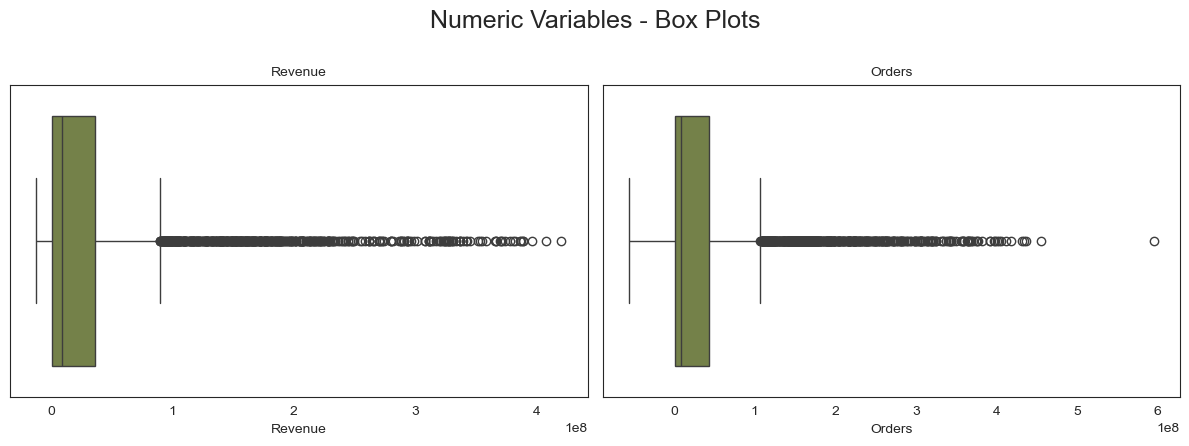

In [61]:
#applying the function to our numerical features
plot_multiple_boxplots(train_data, metric_features_train)

In [62]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

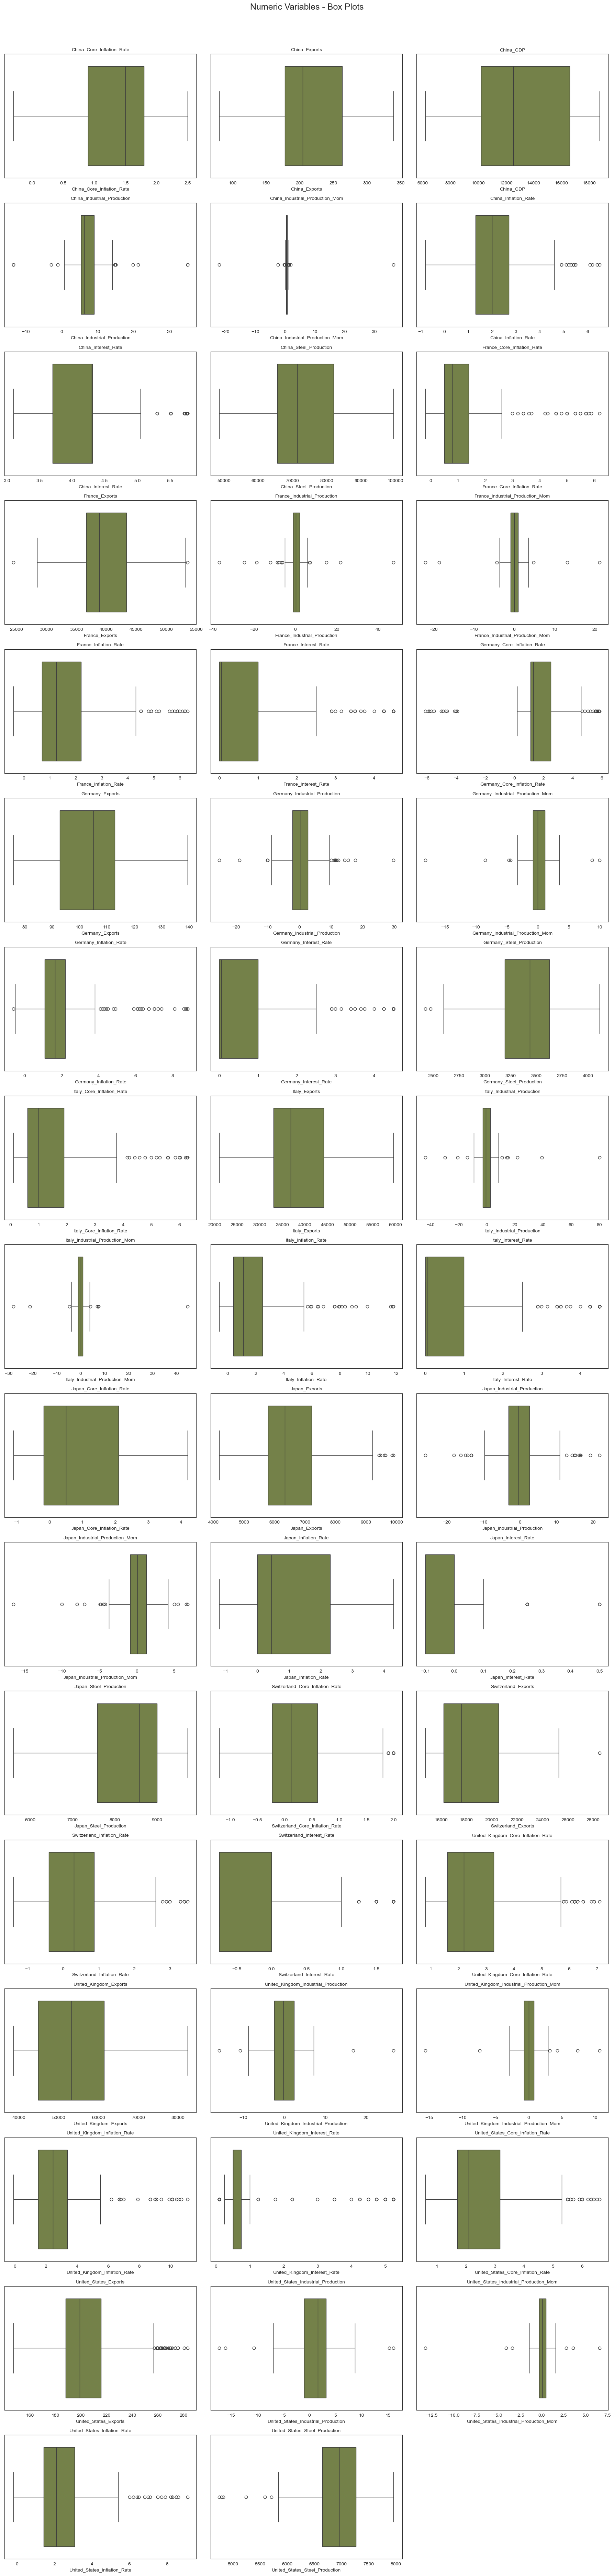

In [63]:
#applying the function to our numerical features
plot_multiple_boxplots(df_market, metric_features_market)

- Even tough there are some outliers, these values correspond to real macroeconomic indicators (like inflation, post-COVID period, etc.). If we applied some capping or transformation to try handle them, we would be distorting the actual economic reality that your model needs to learn from. Therefore, we have decided to keep the data as it is for now. 

### 3.6. Checking Distribution

In [64]:
df= pd.DataFrame(train_data[metric_features_train])

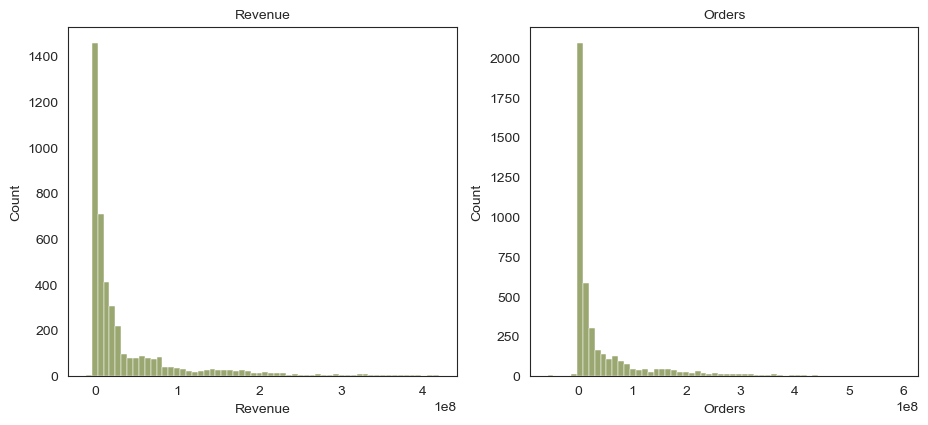

In [65]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = train_data.sample(n=min(N, len(train_data)), random_state=42)

#selecting numeric variables
cols = metric_features_train

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

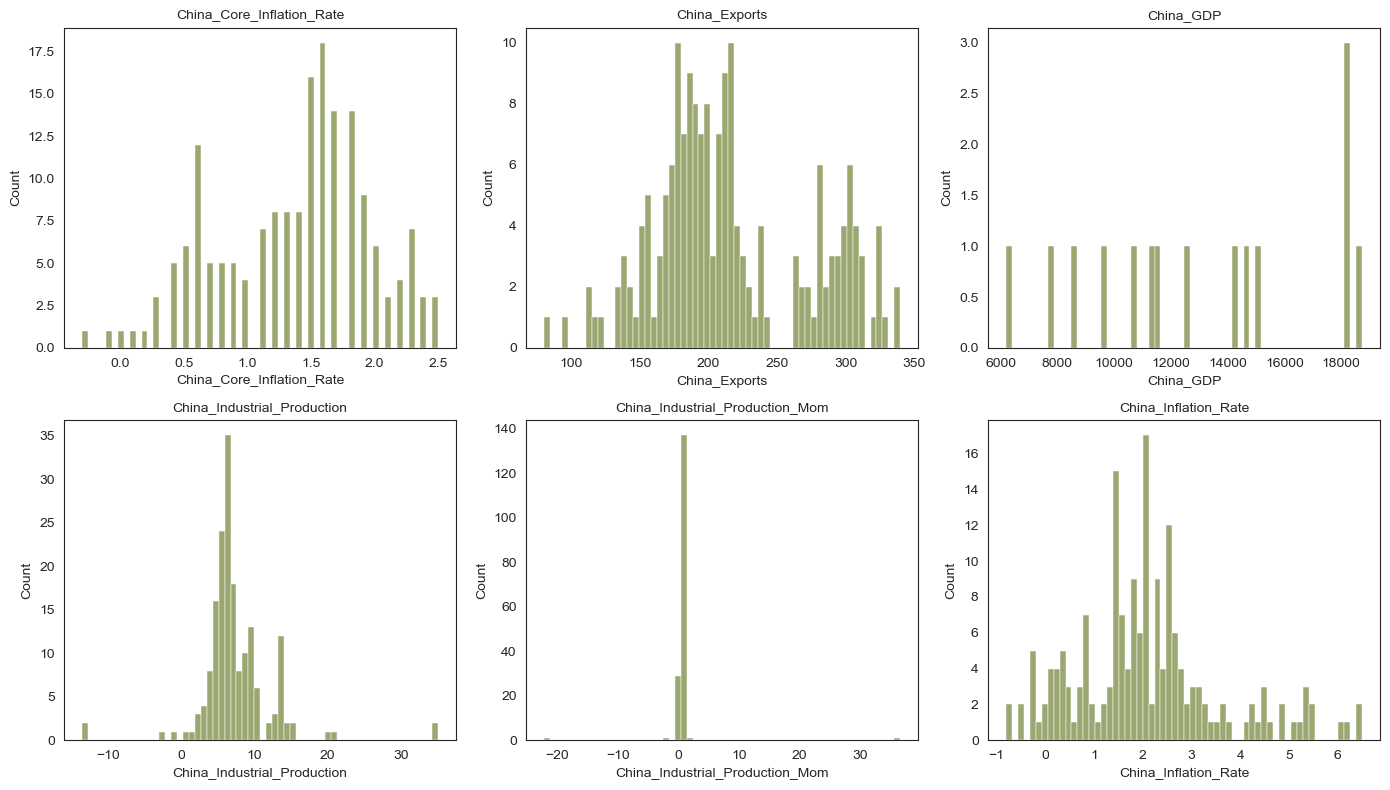

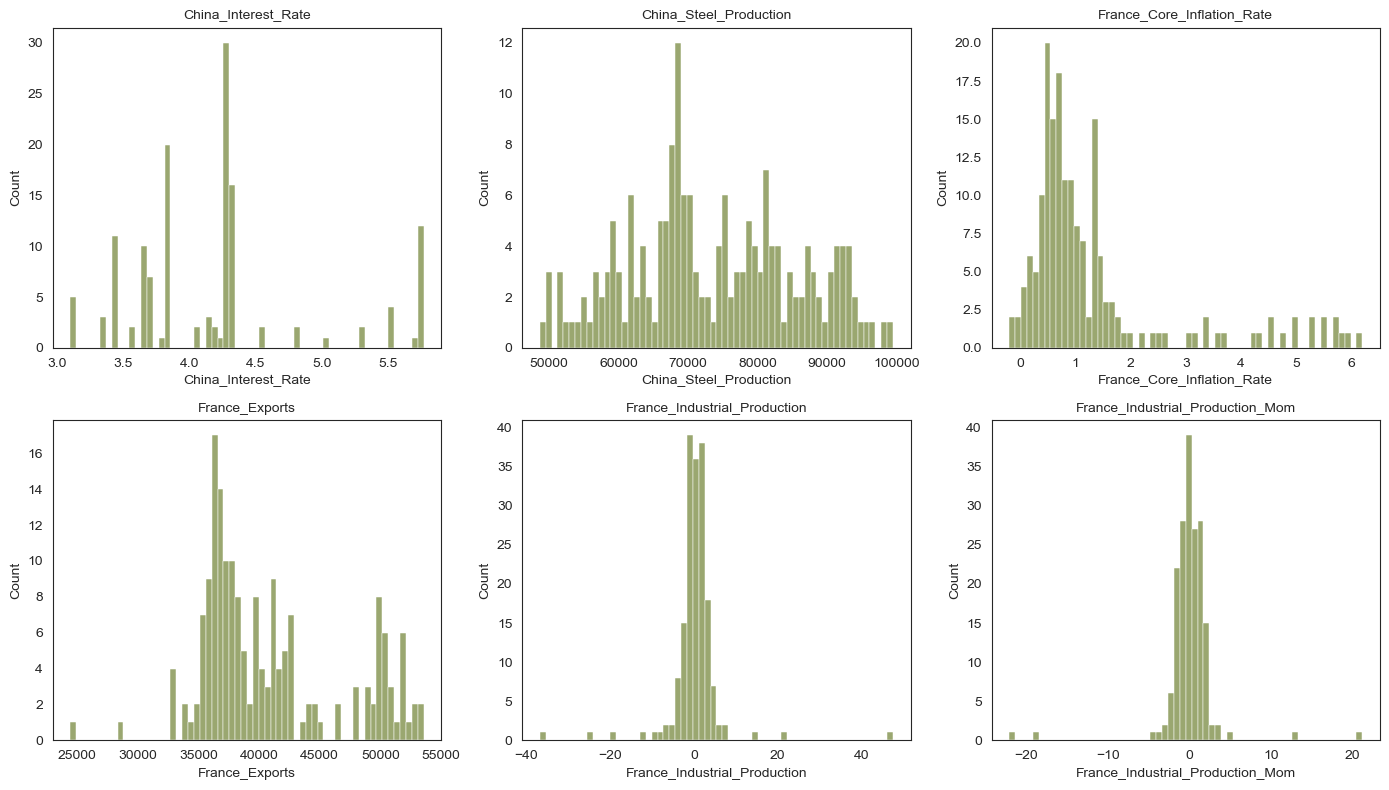

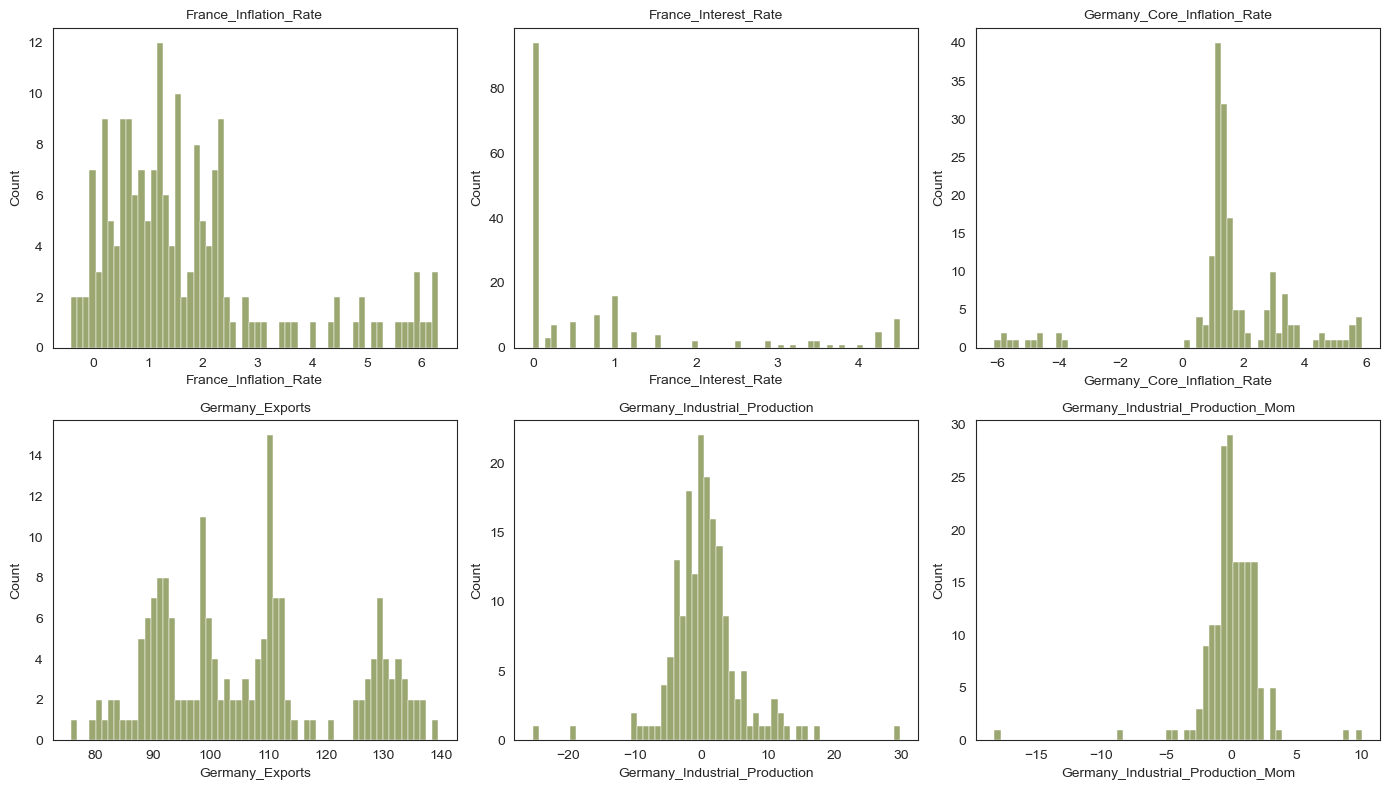

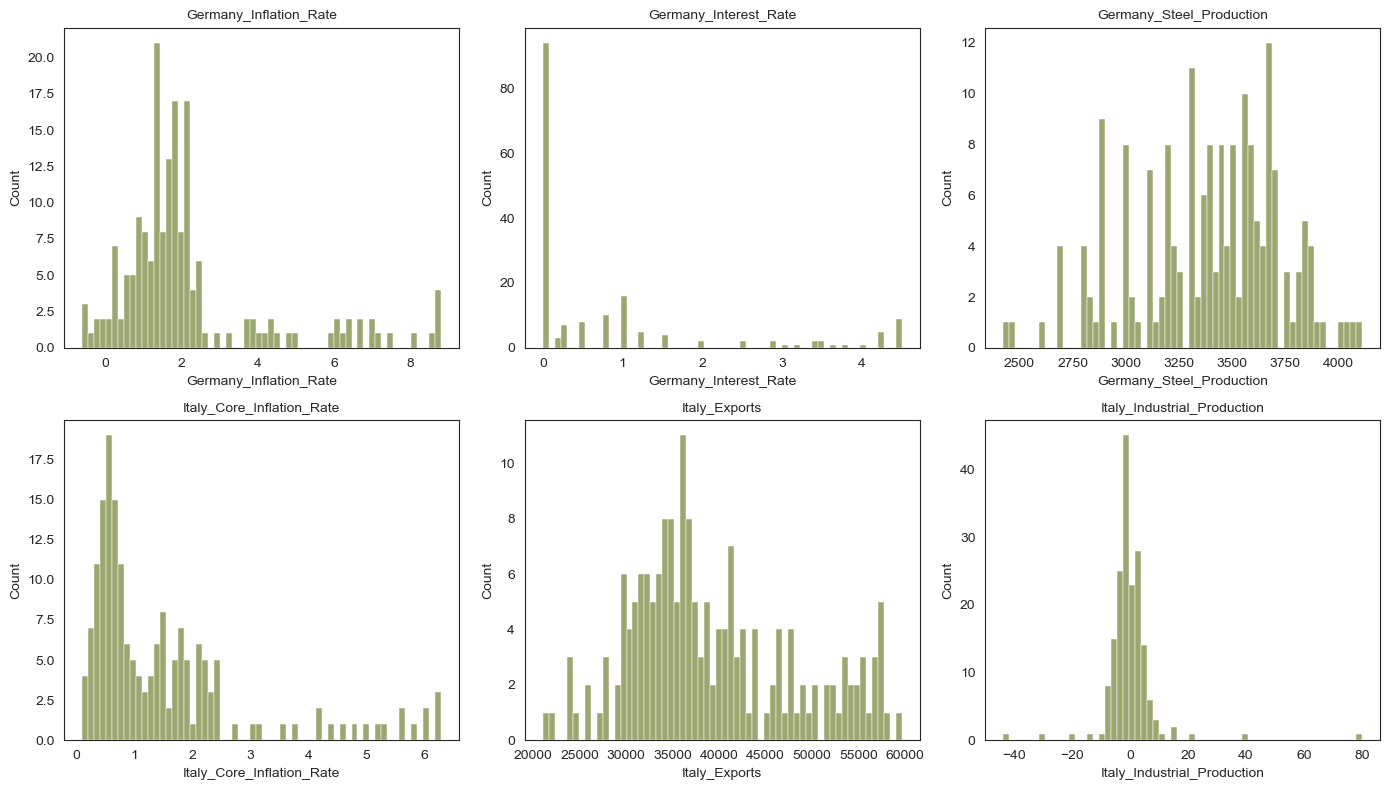

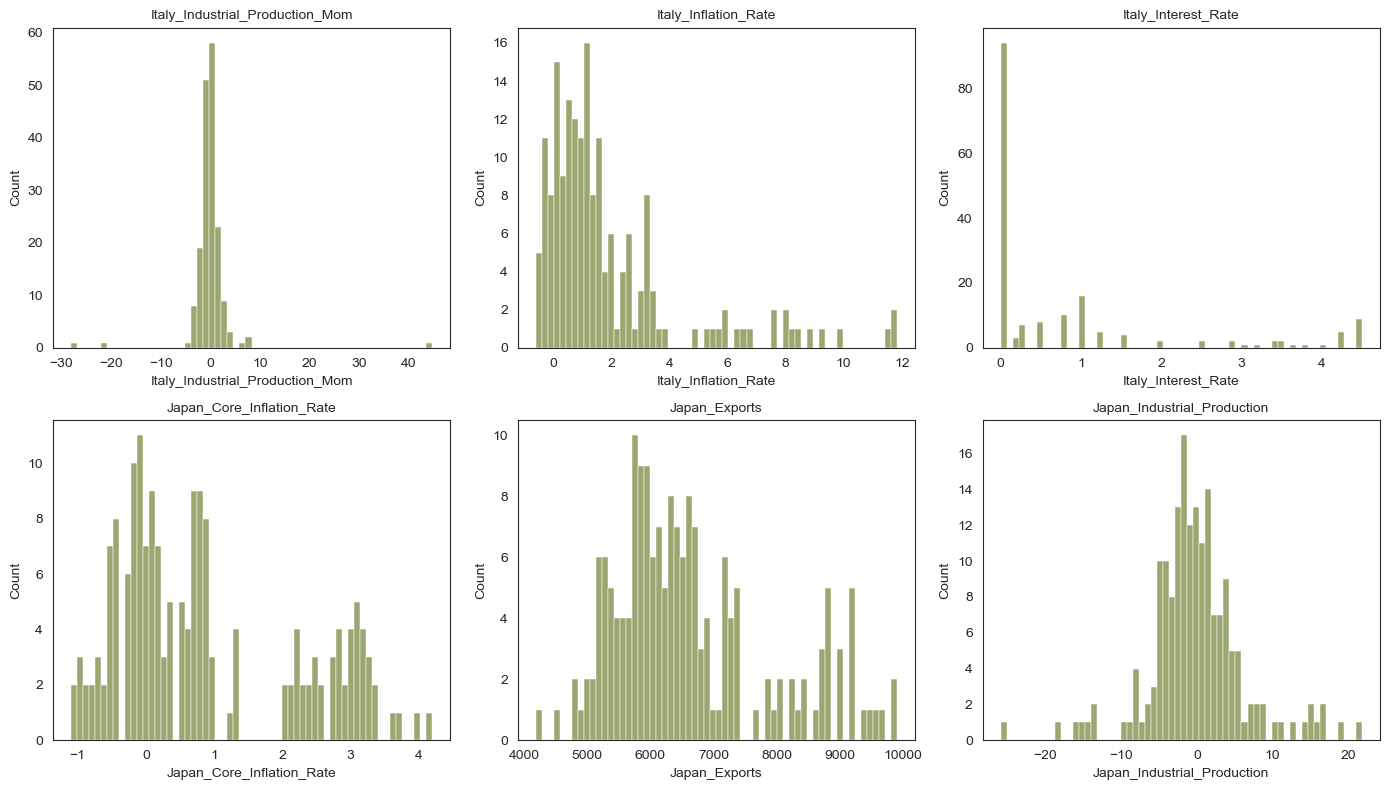

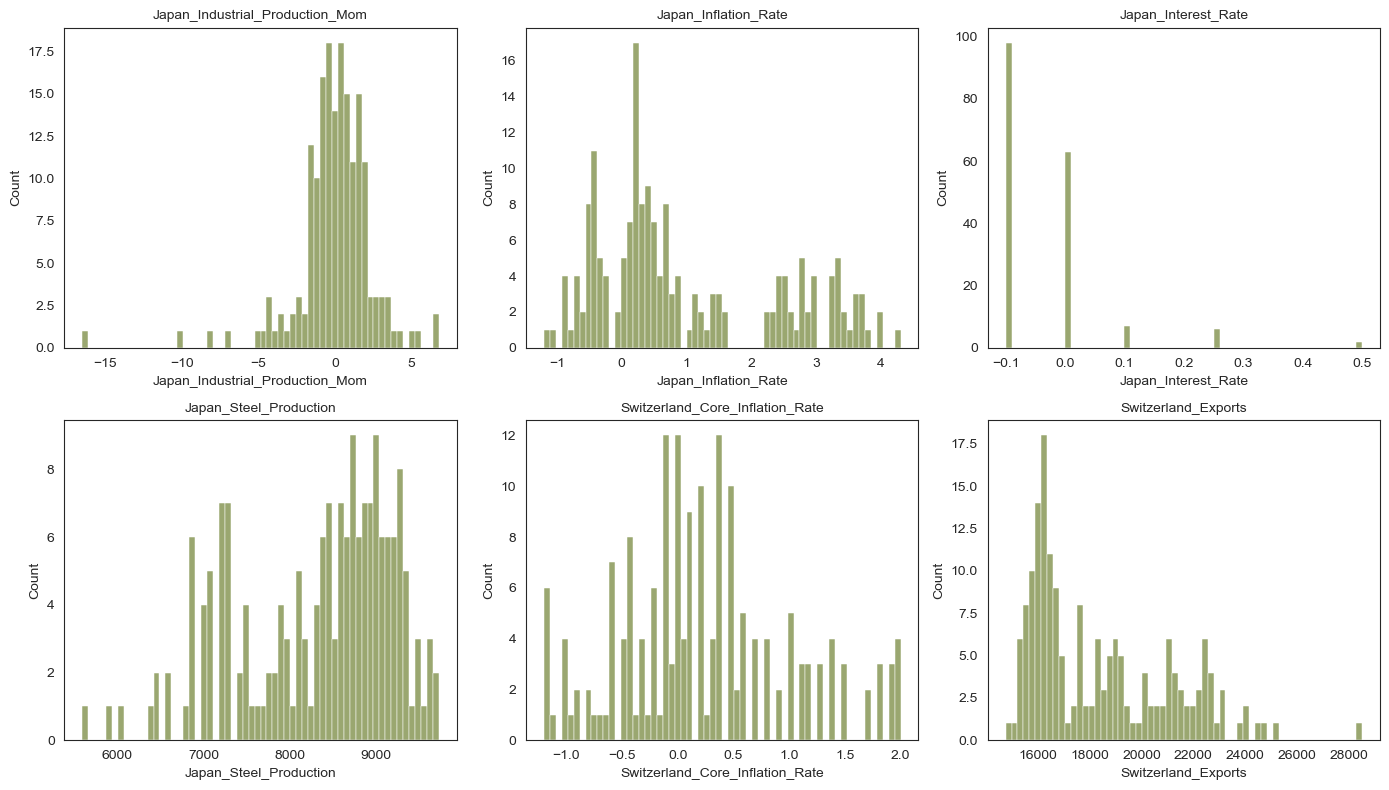

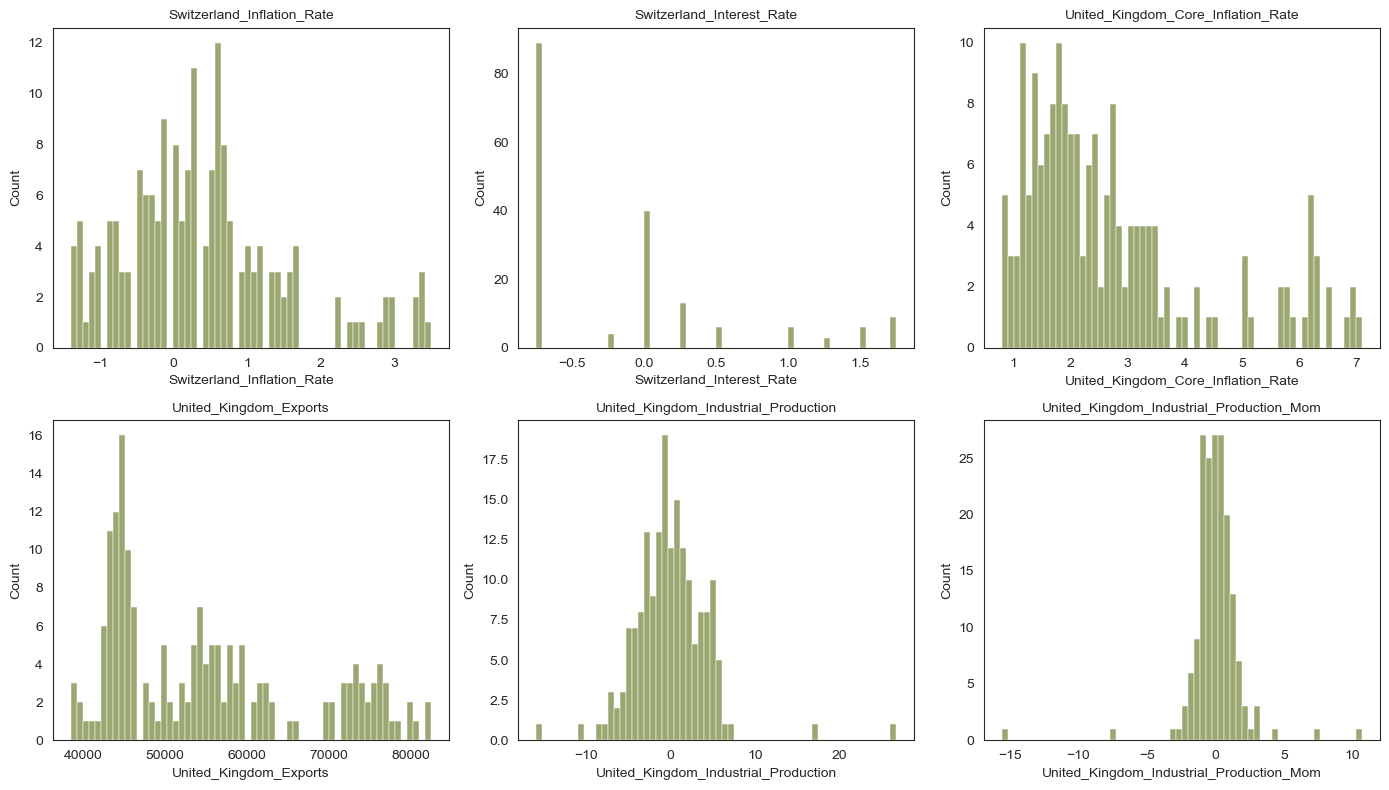

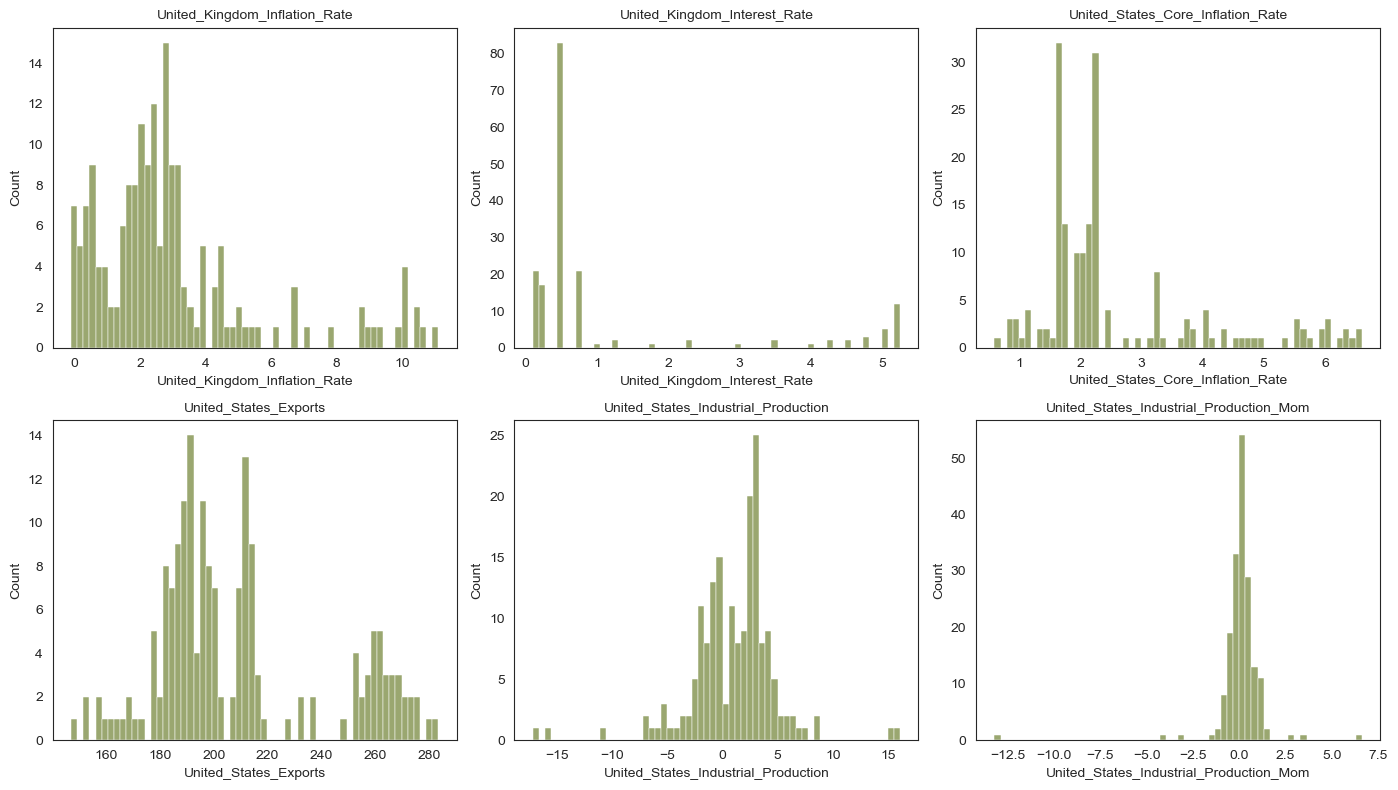

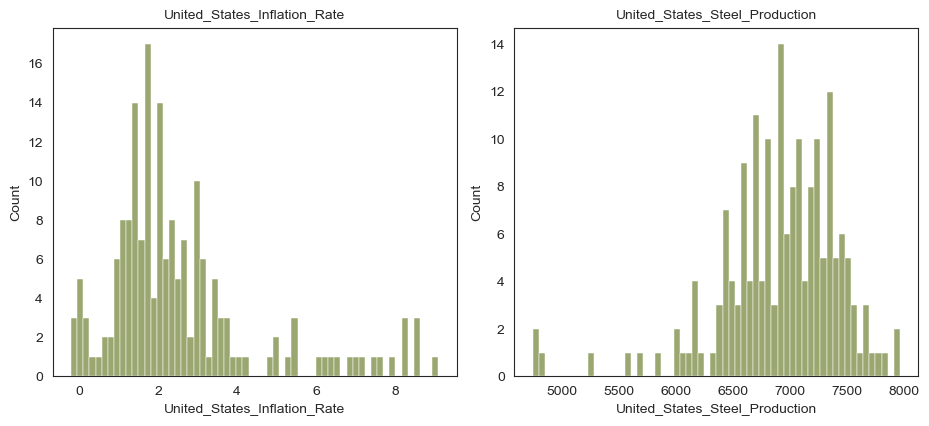

In [66]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = df_market.sample(n=min(N, len(df_market)), random_state=42)

#selecting numeric variables
cols = metric_features_market

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 3.7. Checking Correlation between variables

In [67]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = df_market[metric_features_market].corr(method ='spearman')
cor_spearman

,China_Core_Inflation_Rate,China_Exports,China_GDP,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,China_Steel_Production,France_Core_Inflation_Rate,France_Exports,...,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Steel_Production
China_Core_Inflation_Rate,1.000000,-0.601535,-0.641005,0.350778,0.110067,0.489509,0.763456,-0.519185,-0.470539,-0.445736,...,0.129136,0.063294,-0.045124,-0.278393,-0.419716,-0.410172,0.244042,0.004236,-0.203296,0.346979
China_Exports,-0.601535,1.000000,0.932143,-0.534005,-0.253287,-0.556201,-0.716840,0.765034,0.413557,0.755412,...,-0.067462,-0.037299,0.165909,0.332794,0.594231,0.779905,-0.144228,-0.012998,0.491679,-0.088536
China_GDP,-0.641005,0.932143,1.000000,-0.705988,-0.536429,-0.694721,-0.943685,0.807143,0.481217,0.942857,...,-0.058981,-0.201966,0.175000,0.403616,0.703146,0.910714,-0.480787,-0.304388,0.550985,-0.175000
China_Industrial_Production,0.350778,-0.534005,-0.705988,1.000000,0.483968,0.298135,0.475174,-0.574685,-0.303811,-0.630758,...,0.088079,-0.068754,0.003491,-0.349172,-0.597015,-0.527057,0.388441,0.171938,-0.232295,0.212601
China_Industrial_Production_Mom,0.110067,-0.253287,-0.536429,0.483968,1.000000,0.304943,0.031023,-0.199254,-0.143508,-0.453833,...,-0.057605,-0.015859,-0.015704,-0.163640,-0.408471,-0.410135,-0.062856,0.074491,-0.183883,-0.031805
China_Inflation_Rate,0.489509,-0.556201,-0.694721,0.298135,0.304943,1.000000,0.473119,-0.457820,-0.131786,-0.592795,...,-0.106269,0.034190,0.105715,-0.117586,-0.334955,-0.541774,0.289531,0.082164,-0.142046,0.358545
China_Interest_Rate,0.763456,-0.716840,-0.943685,0.475174,0.031023,0.473119,1.000000,-0.594454,-0.732886,-0.712972,...,0.504204,0.089586,-0.518614,-0.386924,-0.649751,-0.619018,0.170641,-0.071090,-0.632366,0.397936
China_Steel_Production,-0.519185,0.765034,0.807143,-0.574685,-0.199254,-0.457820,-0.594454,1.000000,0.242274,0.664963,...,0.081263,0.012418,-0.018187,0.186418,0.454955,0.655751,-0.306479,0.051236,0.344398,-0.123561
France_Core_Inflation_Rate,-0.470539,0.413557,0.481217,-0.303811,-0.143508,-0.131786,-0.732886,0.242274,1.000000,0.558090,...,-0.434278,-0.130584,0.638881,0.565150,0.710207,0.464588,0.095544,-0.001930,0.687309,-0.015814
France_Exports,-0.445736,0.755412,0.942857,-0.630758,-0.453833,-0.592795,-0.712972,0.664963,0.558090,1.000000,...,-0.053031,-0.020413,0.274422,0.566934,0.774614,0.892917,-0.164116,-0.113626,0.580744,-0.117215


In [68]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

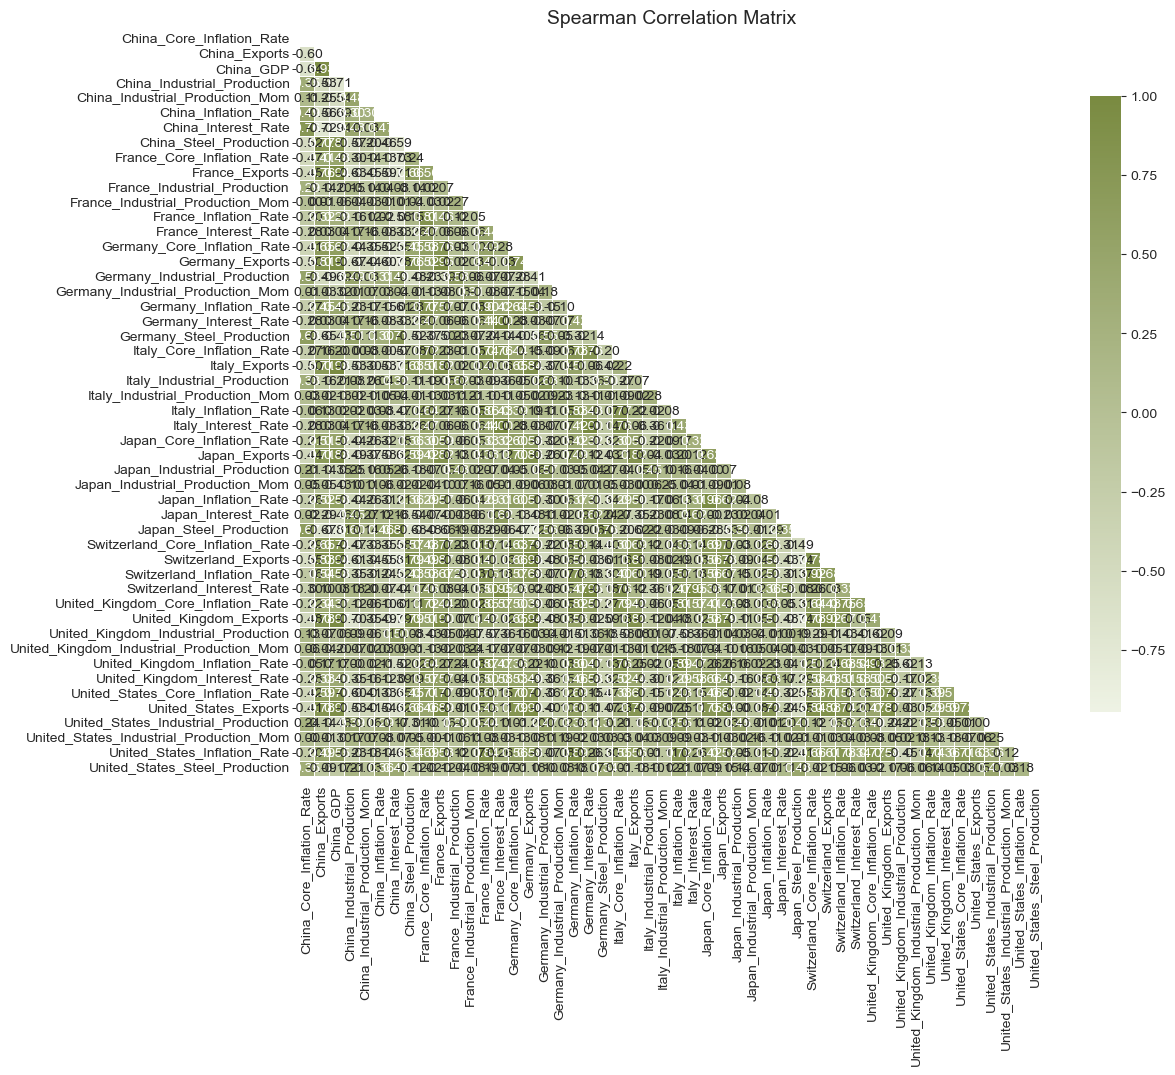

In [69]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

## 4. Data Preparation

### 4.1. Handling Missing Values

- For columns with >50% missing values (corresponding to GDP columns), we have decided to fill the missing observations with the value of the GDP of that year. 
- For columns with <50% missing values, interpolation is going to be applied in order to fill them. 
- Columns whose missing values reach 100% in positive months (corresponding to steel production of some countries), we have decided to drop those columns, since it does not contain relevant information that could be used in the model later on. 

In [70]:
# columns to drop - steel production countries with 100% missing in periods 1-48
cols_to_drop = [
    'France_Steel_Production',
    'Italy_Steel_Production',
    'United_Kingdom_Steel_Production'
]
df_market = df_market.drop(columns=cols_to_drop)

# identify GDP columns (more than 50% missing) vs other columns
missing_pct = df_market.isna().sum() / len(df_market) * 100
gdp_cols    = missing_pct[missing_pct > 50].index.tolist()
other_cols  = missing_pct[(missing_pct > 0) & (missing_pct <= 50)].index.tolist()

print("GDP columns to forward-fill:", gdp_cols)
print("Other columns to interpolate:", other_cols)

# forward-fill GDP columns, then backward-fill any remaining NaNs at the start
df_market = df_market.sort_values('Period').reset_index(drop=True)
df_market[gdp_cols] = df_market[gdp_cols].ffill().bfill()

# linear interpolation for columns with less than 50% missing + ffill/bfill for edges
df_market[other_cols] = df_market[other_cols].interpolate(method='linear').ffill().bfill()

# verify no missing values remain
remaining = df_market.isna().sum()
remaining = remaining[remaining > 0]
print("\nRemaining missing values:")
print(remaining if len(remaining) > 0 else "None - all clean!")

GDP columns to forward-fill: ['China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 'Switzerland_GDP', 'Switzerland_Industrial_Production', 'Switzerland_Industrial_Production_Mom', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_States_GDP', 'United_States_GDP_from_Construction', 'United_States_GDP_from_Manufacturing']
Other columns to interpolate: ['China_Core_Inflation_Rate', 'China_Exports', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production', 'France_Ind

In [71]:
#checking number of missing values
df_market.isna().sum()

Period                                      0
China_Core_Inflation_Rate                   0
China_Exports                               0
China_GDP                                   0
China_GDP_from_Construction                 0
China_GDP_from_Manufacturing                0
China_Industrial_Production                 0
China_Industrial_Production_Mom             0
China_Inflation_Rate                        0
China_Interest_Rate                         0
China_Steel_Production                      0
France_Core_Inflation_Rate                  0
France_Exports                              0
France_GDP                                  0
France_GDP_from_Construction                0
France_GDP_from_Manufacturing               0
France_Industrial_Production                0
France_Industrial_Production_Mom            0
France_Inflation_Rate                       0
France_Interest_Rate                        0
Germany_Core_Inflation_Rate                 0
Germany_Exports                   

### 4.2. Merging Datasets

In [72]:
#merging the datasets on the left
df_merged = train_data.merge(df_market, on='Period', how='left')

print(df_merged.shape)

(4237, 81)


In [73]:
df_merged.head(25)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,3.0,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,3.8,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,4.5,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,4.3,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,4.0,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,14996.41,...,4.0,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,14996.41,...,4.6,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,14996.41,...,4.9,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,18201.70,...,5.5,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,18201.70,...,6.0,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0


In [74]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 81 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   Int32  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   Int32  
 6   Revenue                                   4237 non-null   Int32  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [75]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Period                                      0.0
Biz_Desc                                    0.0
Business_Unit                               0.0
Segment                                     0.0
Subsegment                                  0.0
Orders                                      0.0
Revenue                                     0.0
China_Core_Inflation_Rate                   0.0
China_Exports                               0.0
China_GDP                                   0.0
China_GDP_from_Construction                 0.0
China_GDP_from_Manufacturing                0.0
China_Industrial_Production                 0.0
China_Industrial_Production_Mom             0.0
China_Inflation_Rate                        0.0
China_Interest_Rate                         0.0
China_Steel_Production                      0.0
France_Core_Inflation_Rate                  0.0
France_Exports                              0.0
France_GDP                                  0.0
France_GDP_from_Construction            

In [76]:
# add real dates from period map
df_period_map = df_period_map.dropna(subset=['Period'])
df_period_map['Period'] = df_period_map['Period'].astype(int)
df_merged = df_merged.merge(df_period_map[['Period', 'DATE']], on='Period', how='left')
df_merged = df_merged.rename(columns={'DATE': 'Date'})

print(df_merged[['Period', 'Date']].drop_duplicates().head(10))

   Period       Date
0       1 2021-04-01
1       2 2021-05-01
2       3 2021-06-01
3       4 2021-07-01
4       5 2021-08-01
5       6 2021-09-01
6       7 2021-10-01
7       8 2021-11-01
8       9 2021-12-01
9      10 2022-01-01


In [77]:
df_merged.head()

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01


In [78]:
#exporting dataset
dataset = pd.DataFrame(df_merged)
dataset.to_csv("df_merged.csv", index=False)

### 4.3 Creating our Reconciliation Datasets

Here, we will create a separate dataframe for every hierarchy level (BU, Segment and Subsegment):
- df_subseg for our Subsegment level;
- df_seg for our Segment level;
- df_bu for our Business Unit level.

First, we will specify our target, time column and hierarchy levels, then we will check to see possible incoherences, such as the same subsegment having diferent segments related to it (as well as that relation between segments and BUs).

In [79]:
TARGET = 'Revenue'
TIME_COL = 'Period'
LEVELS = ['Business_Unit', 'Segment', 'Subsegment']

In [80]:
df = df_merged.copy()

subseg_to_segment = (
    df[['Subsegment', 'Segment']]
    .drop_duplicates()
    .groupby('Subsegment')
    .size()
)

print((subseg_to_segment > 1).sum())

segment_to_bu = (
    df[['Segment', 'Business_Unit']]
    .drop_duplicates()
    .groupby('Segment')
    .size()
)

print((segment_to_bu > 1).sum())

0
0


According with the output above, we can see that we don't have a relationship problem between our hirarchy levels.

Now, we will fill missing values in the timelines of every series (specifically in the 'Revenue' and 'Orders' columns), creating our dataset for subsegment level.

In [81]:
df_base = df.copy()

all_periods = sorted(df_base[TIME_COL].unique())

In [82]:
macro_cols = [col for col in df_base.columns if col not in [TIME_COL, 'Business_Unit', 'Segment', 'Subsegment', 'Orders', 'Revenue']]

aligned_list = []

for subseg, grp in df_base.groupby('Subsegment'):
    grp = grp.sort_values(TIME_COL)

    bu = grp['Business_Unit'].iloc[0]
    seg = grp['Segment'].iloc[0]

    grp = grp.set_index(TIME_COL).reindex(all_periods)

    grp['Business_Unit'] = bu
    grp['Segment'] = seg
    grp['Subsegment'] = subseg
    grp.index.name = TIME_COL

    grp[TARGET] = grp[TARGET].fillna(0)
    grp['Orders'] = grp['Orders'].fillna(0)

    for col in macro_cols:
        grp[col] = grp[col].ffill().bfill()

    aligned_list.append(grp.reset_index())

df_subseg = pd.concat(aligned_list, ignore_index=True)

In [83]:
#exemple of a series
df_subseg.head(42)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,14996.41,...,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,14996.41,...,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,14996.41,...,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,18201.70,...,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,18201.70,...,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01


Now, we will create our dataset for segment and BU levels, by aggregating.

In [84]:
agg_dict_segment = {TARGET: 'sum',
                    'Orders': 'sum'}

for col in macro_cols:
    agg_dict_segment[col] = 'first'

df_seg = (
    df_subseg
    .groupby(['Business_Unit', 'Segment', TIME_COL], as_index=False)
    .agg(agg_dict_segment)
)

df_seg.head(42)

,Business_Unit,Segment,Period,Revenue,Orders,Biz_Desc,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
0,SSI027,SSI02710,1,-390277,0,SSI,0.7,263.09,14996.41,11802.2,...,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01
1,SSI027,SSI02710,2,334,0,SSI,0.9,263.23,14996.41,11802.2,...,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01
2,SSI027,SSI02710,3,334,0,SSI,0.9,280.30,14996.41,32730.0,...,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01
3,SSI027,SSI02710,4,1811758,0,SSI,1.3,281.28,14996.41,32730.0,...,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01
4,SSI027,SSI02710,5,80112,0,SSI,1.2,293.17,14996.41,32730.0,...,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01
5,SSI027,SSI02710,6,38468,0,SSI,1.2,304.70,14996.41,53544.1,...,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01
6,SSI027,SSI02710,7,334,0,SSI,1.3,299.12,14996.41,53544.1,...,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01
7,SSI027,SSI02710,8,334,0,SSI,1.2,324.28,14996.41,53544.1,...,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01
8,SSI027,SSI02710,9,-37173,0,SSI,1.2,339.66,18201.70,79269.8,...,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01
9,SSI027,SSI02710,10,38094,0,SSI,1.2,323.28,18201.70,79269.8,...,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01


In [85]:
agg_dict_bu = {TARGET: 'sum',
               'Orders': 'sum'}

for col in macro_cols:
    agg_dict_bu[col] = 'first'

df_bu = (
    df_subseg
    .groupby(['Business_Unit', TIME_COL], as_index=False)
    .agg(agg_dict_bu)
)

df_bu.head(42)

,Business_Unit,Period,Revenue,Orders,Biz_Desc,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
0,SSI027,1,876013101,1177212534,SSI,0.7,263.09,14996.41,11802.2,80538.7,...,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01
1,SSI027,2,1027846570,1179580162,SSI,0.9,263.23,14996.41,11802.2,80538.7,...,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01
2,SSI027,3,1117984921,1171711258,SSI,0.9,280.30,14996.41,32730.0,172698.4,...,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01
3,SSI027,4,923512000,1306674356,SSI,1.3,281.28,14996.41,32730.0,172698.4,...,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01
4,SSI027,5,961854778,1098817802,SSI,1.2,293.17,14996.41,32730.0,172698.4,...,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01
5,SSI027,6,1224480780,1406608790,SSI,1.2,304.70,14996.41,53544.1,265392.2,...,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01
6,SSI027,7,987741396,1065350338,SSI,1.3,299.12,14996.41,53544.1,265392.2,...,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01
7,SSI027,8,1073895101,1108132757,SSI,1.2,324.28,14996.41,53544.1,265392.2,...,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01
8,SSI027,9,1219169591,1370558248,SSI,1.2,339.66,18201.70,79269.8,369903.7,...,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01
9,SSI027,10,1067421235,1172144645,SSI,1.2,323.28,18201.70,79269.8,369903.7,...,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01


In [86]:
agg_dict_total = {TARGET: 'sum',
                  'Orders': 'sum'}

for col in macro_cols:
    agg_dict_total[col] = 'first'

df_total = (
    df_subseg
    .groupby([TIME_COL], as_index=False)
    .agg(agg_dict_total)
)
df_total['node'] = 'TOTAL'

df_total.head(42)

,Period,Revenue,Orders,Biz_Desc,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,...,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,node
0,1,2476687689,3430374690,SSI,0.7,263.09,14996.41,11802.2,80538.7,9.8,...,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01,TOTAL
1,2,2871405827,3499678788,SSI,0.9,263.23,14996.41,11802.2,80538.7,8.8,...,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01,TOTAL
2,3,3131347665,3949155294,SSI,0.9,280.30,14996.41,32730.0,172698.4,8.3,...,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01,TOTAL
3,4,2672503014,3264950469,SSI,1.3,281.28,14996.41,32730.0,172698.4,6.4,...,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01,TOTAL
4,5,2707163488,3232137256,SSI,1.2,293.17,14996.41,32730.0,172698.4,5.3,...,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01,TOTAL
5,6,3588500591,4398275108,SSI,1.2,304.70,14996.41,53544.1,265392.2,3.1,...,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01,TOTAL
6,7,2799145881,3490672966,SSI,1.3,299.12,14996.41,53544.1,265392.2,3.5,...,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01,TOTAL
7,8,3195627034,3754809493,SSI,1.2,324.28,14996.41,53544.1,265392.2,3.8,...,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01,TOTAL
8,9,3688827312,4482519217,SSI,1.2,339.66,18201.70,79269.8,369903.7,4.3,...,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01,TOTAL
9,10,3166659626,3477152271,SSI,1.2,323.28,18201.70,79269.8,369903.7,7.5,...,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01,TOTAL


### 4.4 Hierarchy Matrix

Let's create a diferenciator between the hierarchy levels.

In [87]:
df_subseg['node'] = 'SUBSEG__' + df_subseg['Subsegment'].astype(str)
df_seg['node'] = ('SEG__' + df_seg['Business_Unit'].astype(str) + '__' + df_seg['Segment'].astype(str))
df_bu['node'] = 'BU__' + df_bu['Business_Unit'].astype(str)

In [88]:
hierarchy_df = (
    df_subseg[['Business_Unit', 'Segment', 'Subsegment']]
    .drop_duplicates()
    .copy()
)

hierarchy_df['subseg_node'] = 'SUBSEG__' + hierarchy_df['Subsegment'].astype(str)
hierarchy_df['segment_node'] = (
    'SEG__' + hierarchy_df['Business_Unit'].astype(str) + '__' + hierarchy_df['Segment'].astype(str)
)
hierarchy_df['bu_node'] = 'BU__' + hierarchy_df['Business_Unit'].astype(str)
hierarchy_df['total_node'] = 'TOTAL'

In [89]:
hierarchy_df.head()

,Business_Unit,Segment,Subsegment,subseg_node,segment_node,bu_node,total_node
0,SSI027,SSI02710,SSI02710,SUBSEG__SSI02710,SEG__SSI027__SSI02710,BU__SSI027,TOTAL
42,SSI027,SSI02710,SSI0271002,SUBSEG__SSI0271002,SEG__SSI027__SSI02710,BU__SSI027,TOTAL
84,SSI027,SSI02710,SSI0271004,SUBSEG__SSI0271004,SEG__SSI027__SSI02710,BU__SSI027,TOTAL
126,SSI027,SSI02710,SSI0271006,SUBSEG__SSI0271006,SEG__SSI027__SSI02710,BU__SSI027,TOTAL
168,SSI027,SSI02710,SSI0271099,SUBSEG__SSI0271099,SEG__SSI027__SSI02710,BU__SSI027,TOTAL


In [90]:
base_long = df_subseg[[TIME_COL, 'node', TARGET]].copy()
base_long['level'] = 'Subsegment'

segment_long = df_seg[[TIME_COL, 'node', TARGET]].copy()
segment_long['level'] = 'Segment'

bu_long = df_bu[[TIME_COL, 'node', TARGET]].copy()
bu_long['level'] = 'Business_Unit'

total_long = df_total[[TIME_COL, 'node', TARGET]].copy()
total_long['level'] = 'Total'

all_series_long = pd.concat(
    [base_long, segment_long, bu_long, total_long],
    ignore_index=True
    ).sort_values(['level', 'node', TIME_COL])

## 5. Starting Insights

### 5.1 Baselines Models (AutoETS and SeasonalNaives)

Before we start implementing our baseline models we will check to see how many series we have across the 3 hierarchy levels.

In [91]:
series_dict = {
    node: df.sort_values('Period')['Revenue'].values
    for node, df in all_series_long.groupby('node')
}

len(series_dict)

163

163 series

In [92]:
ts_df = all_series_long[['node', 'Period', 'Revenue']].copy()
ts_df = ts_df.rename(columns={
    'node': 'unique_id',
    'Period': 'ds',
    'Revenue': 'y'
})
ts_df = ts_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

train-val split temporal, deixando as 6 ultimas series como validation set.

In [93]:
HORIZON = 6

Y_train = ts_df.groupby('unique_id').apply(lambda x: x.iloc[:-HORIZON]).reset_index(drop=True)
Y_val   = ts_df.groupby('unique_id').apply(lambda x: x.iloc[-HORIZON:]).reset_index(drop=True)

C:\Users\Catarina\AppData\Local\Temp\ipykernel_14112\342939087.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Y_train = ts_df.groupby('unique_id').apply(lambda x: x.iloc[:-HORIZON]).reset_index(drop=True)
C:\Users\Catarina\AppData\Local\Temp\ipykernel_14112\342939087.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Y_val   = ts_df.groupby('unique_id').apply(lambda x: x.iloc[-HORIZON:]).reset_index(d

treinar ambos os modelos iniciais (AutoETS e SeasonalNaive).

In [94]:
print("\n" + "="*60)
print("Base Models Training")
print("="*60)

models = [
    SeasonalNaive(season_length=12),
    AutoETS(season_length=12),
]

sf = StatsForecast(models=models, freq=1, n_jobs=-1)

print("Training... (1-2 min)")
sf.fit(Y_train)
print("Train OK!")

Y_hat_df = sf.predict(h=HORIZON).reset_index(drop = False)
print(f"Predictions: {Y_hat_df.shape}")


Base Models Training
Training... (1-2 min)
Train OK!
Predictions: (978, 5)


Evaluation dataset:

In [95]:
eval_df = Y_val.merge(Y_hat_df, on=['unique_id', 'ds'], how='inner')
print(eval_df.shape)

if 'index' in eval_df.columns:
    eval_df = eval_df.drop(columns='index')

eval_df.head()

(978, 6)


,unique_id,ds,y,SeasonalNaive,AutoETS
0,BU__SSI027,37,1109162488,1.016890e+09,1.047854e+09
1,BU__SSI027,38,1205301917,1.148847e+09,1.207327e+09
2,BU__SSI027,39,1317853622,1.200080e+09,1.267943e+09
3,BU__SSI027,40,1198767913,1.086916e+09,1.095641e+09
4,BU__SSI027,41,1218656700,1.141048e+09,1.144317e+09


Checking our starting RMSE for each model:

In [96]:
rmse_snaive = np.sqrt(mean_squared_error(eval_df['y'], eval_df['SeasonalNaive']))
print("RMSE global - SeasonalNaive:", rmse_snaive)

rmse_autoets = np.sqrt(mean_squared_error(eval_df['y'], eval_df['AutoETS']))
print("RMSE global - AutoETS:", rmse_autoets)

RMSE global - SeasonalNaive: 43911627.964197
RMSE global - AutoETS: 16852501.08508479


In [97]:
rmse_by_series = []

for uid, grp in eval_df.groupby('unique_id'):
    rmse_s = np.sqrt(mean_squared_error(grp['y'], grp['SeasonalNaive']))
    rmse_a = np.sqrt(mean_squared_error(grp['y'], grp['AutoETS']))
    
    rmse_by_series.append({
        'unique_id': uid,
        'rmse_SeasonalNaive': rmse_s,
        'rmse_AutoETS': rmse_a
    })

rmse_by_series = pd.DataFrame(rmse_by_series)
rmse_by_series.head()

,unique_id,rmse_SeasonalNaive,rmse_AutoETS
0,BU__SSI027,1.017297e+08,6.385161e+07
1,BU__SSI037,2.148585e+08,5.579548e+07
2,BU__SSI047,1.268716e+08,8.552706e+07
3,BU__SSI070,4.297214e+06,7.686637e+06
4,SEG__SSI027__SSI02710,8.946830e+05,8.559879e+05


In [98]:
wins_autoets = (rmse_by_series['rmse_AutoETS'] < rmse_by_series['rmse_SeasonalNaive']).sum()
wins_snaive  = (rmse_by_series['rmse_SeasonalNaive'] < rmse_by_series['rmse_AutoETS']).sum()
ties = ((rmse_by_series['rmse_AutoETS'] == rmse_by_series['rmse_SeasonalNaive']).sum())

print("Series with lower RMSE on AutoETS:", wins_autoets)
print("Series with lower RMSE on SeasonalNaives:", wins_snaive)
print("Series with equal RMSE on AutoETS and SeasonalNaives:", ties)

Series with lower RMSE on AutoETS: 77
Series with lower RMSE on SeasonalNaives: 56
Series with equal RMSE on AutoETS and SeasonalNaives: 30


On the outputs above, we can see that, although AutoETS had a RMSE value of around 27M lower than SeasonalNaives, there were 56 series where SeasonalNaives performed better.

We can also see that 30 series had similar RMSE in both models.

### 5.2 Bottom-Up Reconciliation (AutoETS)

**(BOTTOM-UP ESTÁ A SER USADO COMO VALIDAÇÃO NESTA FASE, NAO SERÁ O FINAL)**

First, let's create a dataframe for our base forecast and separate the diferent hierarchy levels.

In [99]:
#creating our base forecast dataset
base_fcst_df = eval_df[['unique_id', 'ds', 'y', 'AutoETS']].copy()
base_fcst_df = base_fcst_df.rename(columns={'AutoETS': 'base_forecast'})

#separating by the diferent hierarchy levels
subseg_nodes = sorted([uid for uid in base_fcst_df['unique_id'].unique() if uid.startswith('SUBSEG__')])
segment_nodes = sorted([uid for uid in base_fcst_df['unique_id'].unique() if uid.startswith('SEG__')])
bu_nodes = sorted([uid for uid in base_fcst_df['unique_id'].unique() if uid.startswith('BU__')])

mapping between levels

In [100]:
#from subsegment to segment
subseg_to_segment = dict(zip(
    hierarchy_df['subseg_node'],
    hierarchy_df['segment_node']
))

#from segment to business unit
segment_to_bu = dict(zip(
    hierarchy_df['segment_node'],
    hierarchy_df['bu_node']
))

**passo 1:** filtrar por subsegmentos

In [101]:
subseg_df = base_fcst_df[base_fcst_df['unique_id'].isin(subseg_nodes)].copy()

**passo 2:** calcular segmentos

In [102]:
segment_recon = (
    subseg_df
    .assign(segment=lambda x: x['unique_id'].map(subseg_to_segment))
    .groupby(['segment', 'ds'])['base_forecast']
    .sum()
    .reset_index()
    .rename(columns={'segment': 'unique_id'})
)

**passo 3:** calcular bu

In [103]:
bu_recon = (
    segment_recon
    .assign(bu=lambda x: x['unique_id'].map(segment_to_bu))
    .groupby(['bu', 'ds'])['base_forecast']
    .sum()
    .reset_index()
    .rename(columns={'bu': 'unique_id'})
)

**passo 4:** calcular total

In [104]:
total_recon = (
    bu_recon
    .groupby(['ds'])['base_forecast']
    .sum()
    .reset_index()
)

total_recon['unique_id'] = 'TOTAL'

**passo 5:** juntar tudo

In [105]:
reconciled_df = pd.concat([
    subseg_df[['unique_id', 'ds', 'base_forecast']],
    segment_recon,
    bu_recon,
    total_recon
], ignore_index=True)

Now, we will evaluate this reconciled_df:

In [106]:
eval_recon = eval_df[['unique_id', 'ds', 'y']].merge(
    reconciled_df,
    on=['unique_id', 'ds'],
    how='inner'
)

rmse_recon = np.sqrt(mean_squared_error(eval_recon['y'], eval_recon['base_forecast']))
print("RMSE reconciled:", rmse_recon)

RMSE reconciled: 24308285.464294516


In [107]:
rmse_base = np.sqrt(mean_squared_error(eval_df['y'], eval_df['AutoETS']))

print("RMSE base:", rmse_base)
print("RMSE reconciled:", rmse_recon)

RMSE base: 16852501.08508479
RMSE reconciled: 24308285.464294516


In [108]:
t = reconciled_df['ds'].iloc[0]

sub_sum = reconciled_df[
    (reconciled_df['ds'] == t) & 
    (reconciled_df['unique_id'].isin(subseg_nodes))
]['base_forecast'].sum()

total_val = reconciled_df[
    (reconciled_df['ds'] == t) & 
    (reconciled_df['unique_id'] == 'TOTAL')
]['base_forecast'].iloc[0]

print(sub_sum, total_val)

3845954000.0 3845954000.0


### 5.3 MinTrace OLS Reconciliation

In [109]:
all_nodes_list = ['TOTAL'] + sorted(bu_nodes) + sorted(segment_nodes) + sorted(subseg_nodes)
 
n_bottom = len(subseg_nodes)   # 134 subsegments
n_total = len(all_nodes_list)  # 163 series
 
print(f"Total de series: {n_total}")
print(f"Series bottom (subsegments): {n_bottom}")

Total de series: 163
Series bottom (subsegments): 134


In [110]:
# first we will create the matrix S
S = np.zeros((n_total, n_bottom))
 
# mapping the subsegments as indexes in the matrix
subseg_to_idx = {node: i for i, node in enumerate(sorted(subseg_nodes))}

In [111]:
# filling the values in the matrix S
for i, node in enumerate(all_nodes_list):
    if node == 'TOTAL':
        # Total = soma de todos os subsegments
        S[i, :] = 1
    elif node.startswith('BU__'):
        # BU = soma dos subsegments dessa BU
        bu_name = node.replace('BU__', '')
        for subseg in subseg_nodes:
            # Verificar se este subseg pertence a esta BU
            if subseg in subseg_to_segment:
                seg = subseg_to_segment[subseg]
                if seg in segment_to_bu and segment_to_bu[seg] == node:
                    S[i, subseg_to_idx[subseg]] = 1
    elif node.startswith('SEG__'):
        # Segment = soma dos subsegments desse segment
        for subseg in subseg_nodes:
            if subseg in subseg_to_segment and subseg_to_segment[subseg] == node:
                S[i, subseg_to_idx[subseg]] = 1
    elif node.startswith('SUBSEG__'):
        # Subsegment = ele próprio (matriz identidade)
        S[i, subseg_to_idx[node]] = 1
 
S_df = pd.DataFrame(S, index=all_nodes_list, columns=sorted(subseg_nodes))
 
print(f"\nMatriz S shape: {S_df.shape}")
print(f"Verificação - soma da linha TOTAL: {int(S_df.loc['TOTAL'].sum())}")


Matriz S shape: (163, 134)
Verificação - soma da linha TOTAL: 134


After creating the X Matrix, we need to create our Reconciliation function and prepare our base predictions

In [112]:
# Reconciliation MinTrace OLS
 
def reconcile_mintrace_ols(Y_hat_matrix, S_matrix):
    """
    Args:
        Y_hat_matrix: previsões base (n_series x n_horizons) - numpy array
        S_matrix: matriz de agregação (n_series x n_bottom) - numpy array
    
    Returns:
        Previsões reconciliadas (n_series x n_horizons)
    """
    # ensuring the numpy arrays
    if isinstance(Y_hat_matrix, pd.DataFrame):
        Y_hat_matrix = Y_hat_matrix.values
    if isinstance(S_matrix, pd.DataFrame):
        S_matrix = S_matrix.values
    
    # calculating the projection matrix
    StS = S_matrix.T @ S_matrix
    StS_inv = np.linalg.inv(StS)
    P = S_matrix @ StS_inv @ S_matrix.T
    
    # applying reconciliation
    Y_reconciled = P @ Y_hat_matrix
    
    return Y_reconciled

In [113]:
# we will use the base predictions from the eval_df to all series (subsegments, segments, BUs, total)
 
# creating pivot (rows: series, columns: periods)
Y_hat_pivot = eval_df.pivot(index='unique_id', columns='ds', values='AutoETS')
 
# reordering to match the order of the S matrix
Y_hat_pivot = Y_hat_pivot.reindex(all_nodes_list)
 
print(f"\nPrevisões base shape: {Y_hat_pivot.shape}")
 
# checking for NaN values before reconciliation
nan_count = Y_hat_pivot.isna().sum().sum()
if nan_count > 0:
    print(f"{nan_count} valores NaN in the predictions")
else:
    print("No NaNs in the predictions")
 


Previsões base shape: (163, 6)
No NaNs in the predictions


Now we will apply the MinTrace OLS Reconciliation

In [114]:
Y_reconciled_matrix = reconcile_mintrace_ols(Y_hat_pivot.values, S_df.values)
 
# converting to DataFrame
Y_reconciled_mintrace = pd.DataFrame(
    Y_reconciled_matrix,
    index=all_nodes_list,
    columns=Y_hat_pivot.columns
)

In [115]:
Y_actual_pivot = eval_df.pivot(index='unique_id', columns='ds', values='y')
Y_actual_pivot = Y_actual_pivot.reindex(all_nodes_list)
 
# RMSE function
def calc_rmse(actual, predicted):
    # Converter para float (esta linha resolve o erro!)
    actual_flat = actual.values.flatten().astype(float)
    pred_flat = predicted.values.flatten().astype(float)
    
    mask = ~(np.isnan(actual_flat) | np.isnan(pred_flat))
    
    if mask.sum() == 0:
        return np.nan
    
    return np.sqrt(mean_squared_error(actual_flat[mask], pred_flat[mask]))
 
# RMSE Global
rmse_base = calc_rmse(Y_actual_pivot, Y_hat_pivot)
rmse_mintrace = calc_rmse(Y_actual_pivot, Y_reconciled_mintrace)

In [116]:
# using the bottom-up forecasts in the same format for comparison
Y_bottomup_pivot = reconciled_df.pivot(index='unique_id', columns='ds', values='base_forecast')
Y_bottomup_pivot = Y_bottomup_pivot.reindex(all_nodes_list)

# calculate the RMSE of the 3 methods
rmse_base = calc_rmse(Y_actual_pivot, Y_hat_pivot)
rmse_bottomup = calc_rmse(Y_actual_pivot, Y_bottomup_pivot)
rmse_mintrace = calc_rmse(Y_actual_pivot, Y_reconciled_mintrace)

print(f"RMSE Base:      {rmse_base:,.0f}")
print(f"RMSE Bottom-Up: {rmse_bottomup:,.0f}")
print(f"RMSE MinTrace:  {rmse_mintrace:,.0f}")

RMSE Base:      16,852,501
RMSE Bottom-Up: 24,308,281
RMSE MinTrace:  15,654,565


Now we calculate the RMSE for each level

In [117]:
levels = {
    'Total': ['TOTAL'],
    'Business Unit': [n for n in all_nodes_list if n.startswith('BU__')],
    'Segment': [n for n in all_nodes_list if n.startswith('SEG__')],
    'Subsegment': [n for n in all_nodes_list if n.startswith('SUBSEG__')],
}
 

In [118]:
results_by_level = []
 
for level_name, nodes in levels.items():
    actual = Y_actual_pivot.loc[nodes].values.flatten()
    base = Y_hat_pivot.loc[nodes].values.flatten()
    bottomup = Y_bottomup_pivot.loc[nodes].values.flatten()
    mintrace = Y_reconciled_mintrace.loc[nodes].values.flatten()
    
    
    rmse_b = np.sqrt(mean_squared_error(actual, base))
    rmse_bu = np.sqrt(mean_squared_error(actual, bottomup))
    rmse_mt = np.sqrt(mean_squared_error(actual, mintrace))
    
    results_by_level.append({
        'Nível': level_name,
        'Base': rmse_b,
        'Bottom-Up': rmse_bu,
        'MinTrace': rmse_mt,
    })
    
    print(f"\n{level_name}:")
    print(f"  Base:       {rmse_b:>15,.0f}")
    print(f"  Bottom-Up:  {rmse_bu:>15,.0f}")
    print(f"  MinTrace:   {rmse_mt:>15,.0f}")
 
# DataFrame com resultados
results_df = pd.DataFrame(results_by_level)


Total:
  Base:           117,531,672
  Bottom-Up:      196,637,882
  MinTrace:       113,739,279

Business Unit:
  Base:            60,340,960
  Bottom-Up:       79,697,411
  MinTrace:        50,866,561

Segment:
  Base:            18,880,515
  Bottom-Up:       30,877,730
  MinTrace:        18,357,056

Subsegment:
  Base:             8,357,639
  Bottom-Up:        8,357,639
  MinTrace:         7,998,067


## 6. ML Aproach

### 6.1. Feature Engineering

In [ ]:
df = df_subseg.copy()

cols_to_drop = ['Biz_Desc', 'Business_Unit', 'Segment', 'Subsegment', 'Date', 'Orders']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df = df.rename(columns={
    'node': 'unique_id',
    'Revenue': 'y'
})

df = df.sort_values(['unique_id', 'Period'])

In [ ]:
df_full = all_series_long.rename(columns={
    'node': 'unique_id',
    'Revenue': 'y'
})

df_full = df_full.sort_values(['unique_id', 'Period']).reset_index(drop=True)

# Extrair nível hierárquico do prefixo
df['level'] = df['unique_id'].apply(
    lambda x: 0 if x == 'TOTAL'
    else 1 if x.startswith('BU__')
    else 2 if x.startswith('SEG__')
    else 3  # SUBSEG__
)

# Label encode o unique_id para o modelo distinguir séries individuais
le = LabelEncoder()
df['unique_id_enc'] = le.fit_transform(df['unique_id'])

#### 6.1.1 Lags

In [157]:
lags = [1, 3, 6, 9]

for lag in lags:
    df[f'y_lag_{lag}'] = df.groupby('unique_id')['y'].shift(lag)
    

#### 6.1.2 Roling Features

In [158]:
windows = [3, 6, 9]

for w in windows:
    df[f'y_roll_mean_{w}'] = df.groupby('unique_id')['y'].shift(1).rolling(w).mean()
    #df[f'y_roll_std_{w}'] = df.groupby('unique_id')['y'].shift(1).rolling(w).std()

#### 6.1.3 Time Features

In [159]:
df['time_idx'] = df.groupby('unique_id').cumcount()
df['month'] = df['Period'] % 12

#### 6.1.4 Macro Features

In [160]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
macro_cols = [col for col in numeric_cols if col not in ['unique_id', 'Period', 'y']]

macro_lags = [1, 3, 6]

for col in macro_cols:
    if col.startswith('y_') or col in ['time_idx', 'month']:
        continue
    
    for lag in macro_lags:
        df[f'{col}_lag_{lag}'] = df.groupby('unique_id')[col].shift(lag)

#### 6.1.5 Final Preprocessed Dataset

In [161]:
df_model = df.dropna().copy()

target = 'y'

features = [
    col for col in df_model.columns
    if col not in ['y', 'unique_id', 'Period']
]

### 6.2. Feature Selection

#### 6.2.1 Temporal Split (Expanding Window)

In [162]:
expanding_folds = [
    {'train_end': 24, 'val_start': 25, 'val_end': 30},
    {'train_end': 30, 'val_start': 31, 'val_end': 36},
    {'train_end': 36, 'val_start': 37, 'val_end': 42},
]

In [163]:
def get_expanding_fold(df, train_end, val_start, val_end):
    train_df = df[df['Period'] <= train_end].copy()
    val_df = df[(df['Period'] >= val_start) & (df['Period'] <= val_end)].copy()
    return train_df, val_df

In [164]:
for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    print(f"Fold {i}")
    print("Train shape:", train_df.shape)
    print("Val shape:", val_df.shape)
    print("-"*40)

Fold 1
Train shape: (2445, 16)
Val shape: (978, 16)
----------------------------------------
Fold 2
Train shape: (3423, 16)
Val shape: (978, 16)
----------------------------------------
Fold 3
Train shape: (4401, 16)
Val shape: (978, 16)
----------------------------------------


In [165]:
feature_cols = [c for c in df_model.columns if c not in ['unique_id', 'Period', 'y']]
print(f"Number of features: {len(feature_cols)}")

Number of features: 13


#### 6.2.2 XGBoost

In [166]:
fold_feature_importances = []
fold_top_features = []
fold_rmse = []

TOP_N = 15

for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    X_train = train_df[feature_cols]
    y_train = train_df['y']
    
    X_val = val_df[feature_cols]
    y_val = val_df['y']
    
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    fold_rmse.append({
        'fold': i,
        'rmse': rmse
    })
    
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_,
        'fold': i
    }).sort_values('importance', ascending=False)
    
    fold_feature_importances.append(importance_df)
    
    top_features = importance_df.head(TOP_N).copy()
    fold_top_features.append(top_features)
    
    print(f"Fold {i} RMSE: {rmse:,.2f}")
    print(top_features[['feature', 'importance']])
    print("-" * 60)

Fold 1 RMSE: 30,595,796.31
                feature  importance
10  unique_id_enc_lag_1    0.223236
0         unique_id_enc    0.179236
2               y_lag_3    0.153745
3               y_lag_6    0.120983
5         y_roll_mean_3    0.103825
12  unique_id_enc_lag_6    0.082046
6         y_roll_mean_6    0.055825
7         y_roll_mean_9    0.029003
4               y_lag_9    0.023097
11  unique_id_enc_lag_3    0.015723
1               y_lag_1    0.010982
9                 month    0.001548
8              time_idx    0.000754
------------------------------------------------------------
Fold 2 RMSE: 41,363,315.20
                feature  importance
10  unique_id_enc_lag_1    0.348087
2               y_lag_3    0.125979
0         unique_id_enc    0.119044
4               y_lag_9    0.118204
3               y_lag_6    0.113829
7         y_roll_mean_9    0.078013
12  unique_id_enc_lag_6    0.054689
6         y_roll_mean_6    0.021483
5         y_roll_mean_3    0.016353
1               y_lag

In [167]:
all_top_features = pd.concat(fold_top_features, ignore_index=True)
feature_frequency = (
    all_top_features
    .groupby('feature')
    .size()
    .reset_index(name='n_folds_in_topN')
    .sort_values(['n_folds_in_topN', 'feature'], ascending=[False, True])
)

feature_frequency

,feature,n_folds_in_topN
0,month,3
1,time_idx,3
2,unique_id_enc,3
3,unique_id_enc_lag_1,3
4,unique_id_enc_lag_3,3
5,unique_id_enc_lag_6,3
6,y_lag_1,3
7,y_lag_3,3
8,y_lag_6,3
9,y_lag_9,3


In [168]:
all_importances = pd.concat(fold_feature_importances, ignore_index=True)

mean_importance = (
    all_importances
    .groupby('feature', as_index=False)['importance']
    .mean()
    .sort_values('importance', ascending=False)
)

mean_importance.head(10)

,feature,importance
3,unique_id_enc_lag_1,0.302142
8,y_lag_6,0.169779
2,unique_id_enc,0.162804
7,y_lag_3,0.112545
9,y_lag_9,0.056560
10,y_roll_mean_3,0.048921
12,y_roll_mean_9,0.046244
5,unique_id_enc_lag_6,0.045696
11,y_roll_mean_6,0.040543
4,unique_id_enc_lag_3,0.007533


#### 6.2.3 Lasso

In [169]:
fold_lasso_coefs = []
fold_lasso_selected = []
fold_lasso_rmse = []

for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    X_train = train_df[feature_cols]
    y_train = train_df['y']
    
    X_val = val_df[feature_cols]
    y_val = val_df['y']
    
    lasso_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(
            cv=5,
            random_state=42,
            max_iter=20000,
            n_jobs=-1
        ))
    ])
    
    lasso_pipe.fit(X_train, y_train)
    
    y_pred = lasso_pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    fold_lasso_rmse.append({
        'fold': i,
        'rmse': rmse,
        'alpha': lasso_pipe.named_steps['lasso'].alpha_
    })
    
    coefs = lasso_pipe.named_steps['lasso'].coef_
    
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coef': coefs,
        'abs_coef': np.abs(coefs),
        'fold': i
    }).sort_values('abs_coef', ascending=False)
    
    fold_lasso_coefs.append(coef_df)
    
    selected_df = coef_df[coef_df['coef'] != 0].copy()
    fold_lasso_selected.append(selected_df)
    
    print(f"Fold {i} RMSE: {rmse:,.2f}")
    print(f"Selected features: {len(selected_df)}")
    print(f"Chosen alpha: {lasso_pipe.named_steps['lasso'].alpha_}")
    print(selected_df[['feature', 'coef', 'abs_coef']].sort_values(by = 'abs_coef', ascending=False).head(10))
    print("-" * 60)

Fold 1 RMSE: 32,727,809.48
Selected features: 6
Chosen alpha: 340305.67249436665
         feature          coef      abs_coef
3        y_lag_6  1.784762e+08  1.784762e+08
5  y_roll_mean_3  9.338041e+07  9.338041e+07
2        y_lag_3  6.712123e+07  6.712123e+07
4        y_lag_9  2.648645e+06  2.648645e+06
8       time_idx -1.089056e+06  1.089056e+06
9          month  6.187992e+05  6.187992e+05
------------------------------------------------------------
Fold 2 RMSE: 36,974,847.57
Selected features: 5
Chosen alpha: 340391.4638027112
         feature          coef      abs_coef
3        y_lag_6  1.844686e+08  1.844686e+08
5  y_roll_mean_3  1.083852e+08  1.083852e+08
2        y_lag_3  4.885322e+07  4.885322e+07
8       time_idx -2.201253e+06  2.201253e+06
9          month  1.014558e+06  1.014558e+06
------------------------------------------------------------
Fold 3 RMSE: 33,515,964.54
Selected features: 5
Chosen alpha: 351580.23354330135
         feature          coef      abs_coef
3     

#### 6.2.4 Final Insights

In [170]:
# Frequência do Lasso: quantos folds cada feature foi seleccionada (coef != 0)
all_lasso_selected = pd.concat(fold_lasso_selected, ignore_index=True)

lasso_frequency = (
    all_lasso_selected
    .groupby('feature')
    .agg(
        lasso_folds=('fold', 'count'),
        mean_abs_coef=('abs_coef', 'mean')
    )
    .reset_index()
    .sort_values(['lasso_folds', 'mean_abs_coef'], ascending=[False, False])
)

In [171]:
feature_selection_summary = mean_importance.merge(
    feature_frequency,
    on='feature',
    how='left'
).fillna({'n_folds_in_topN': 0})

feature_selection_summary = feature_selection_summary.sort_values(
    ['n_folds_in_topN', 'importance'],
    ascending=[False, False]
).reset_index(drop=True)

In [172]:
# Juntar XGBoost + Lasso numa tabela combinada
combined = (
    feature_frequency
    .rename(columns={'n_folds_in_topN': 'xgb_folds'})
    .merge(lasso_frequency[['feature', 'lasso_folds', 'mean_abs_coef']],
           on='feature', how='outer')
    .fillna(0)
)
combined['xgb_folds']   = combined['xgb_folds'].astype(int)
combined['lasso_folds'] = combined['lasso_folds'].astype(int)
combined['total_score'] = combined['xgb_folds'] + combined['lasso_folds']
combined = combined.sort_values('total_score', ascending=False).reset_index(drop=True)

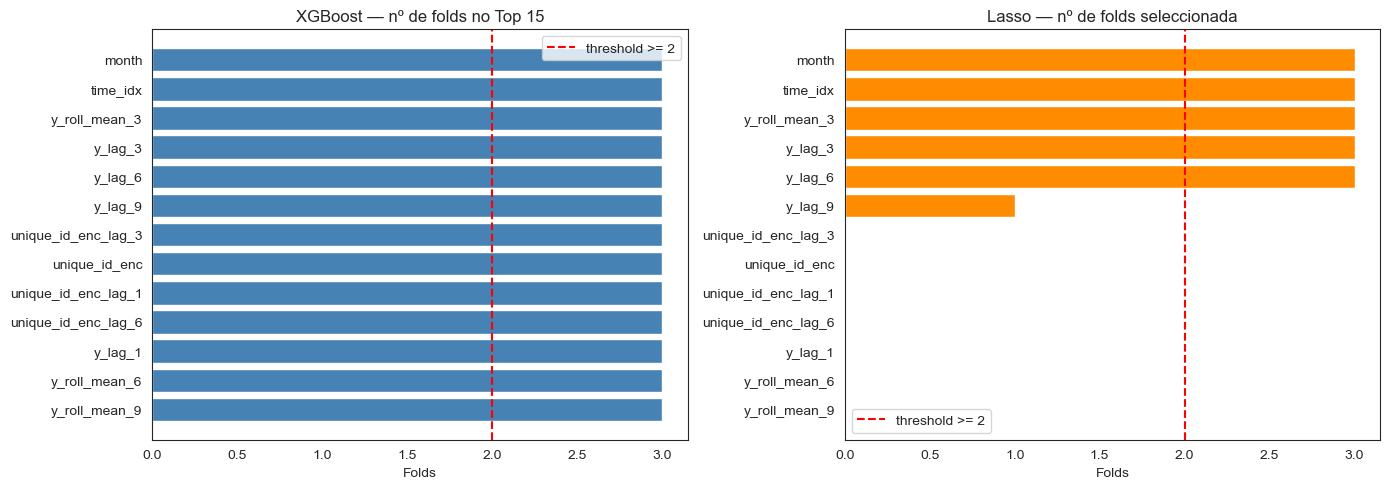

In [173]:
# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
top_xgb = combined.nlargest(20, 'xgb_folds')[['feature', 'xgb_folds']].iloc[::-1]
axes[0].barh(top_xgb['feature'], top_xgb['xgb_folds'], color='steelblue')
axes[0].axvline(x=2, color='red', linestyle='--', label='threshold >= 2')
axes[0].set_title('XGBoost — nº de folds no Top 15')
axes[0].set_xlabel('Folds')
axes[0].legend()

# Lasso
top_lasso = combined.nlargest(20, 'lasso_folds')[['feature', 'lasso_folds']].iloc[::-1]
axes[1].barh(top_lasso['feature'], top_lasso['lasso_folds'], color='darkorange')
axes[1].axvline(x=2, color='red', linestyle='--', label='threshold >= 2')
axes[1].set_title('Lasso — nº de folds seleccionada')
axes[1].set_xlabel('Folds')
axes[1].legend()

plt.tight_layout()
plt.show()

In [174]:
final_features = feature_selection_summary.head(10)['feature'].tolist()
#lasso_selected_features = combined[combined['lasso_folds'] >= 2]
final_features

['unique_id_enc_lag_1',
 'y_lag_6',
 'unique_id_enc',
 'y_lag_3',
 'y_lag_9',
 'y_roll_mean_3',
 'y_roll_mean_9',
 'unique_id_enc_lag_6',
 'y_roll_mean_6',
 'unique_id_enc_lag_3']

## 7. Modeling

### 7.1 Baseline Models

#### 7.1.1 XGBoost

In [175]:
xgb_results = []

for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    X_train = train_df[final_features]
    y_train = train_df['y']
    
    X_val = val_df[final_features]
    y_val = val_df['y']
    
    model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    xgb_results.append(rmse)
    
    print(f"XGBoost Fold {i} RMSE: {rmse:,.2f}")

print("XGBoost Mean RMSE:", np.mean(xgb_results))

XGBoost Fold 1 RMSE: 56,082,896.28
XGBoost Fold 2 RMSE: 57,063,578.61
XGBoost Fold 3 RMSE: 66,098,883.96
XGBoost Mean RMSE: 59748452.95289167


In [176]:
lgbm_results = []

for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    X_train = train_df[final_features]
    y_train = train_df['y']
    
    X_val = val_df[final_features]
    y_val = val_df['y']
    
    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    lgbm_results.append(rmse)
    
    print(f"LightGBM Fold {i} RMSE: {rmse:,.2f}")

print("LightGBM Mean RMSE:", np.mean(lgbm_results))

LightGBM Fold 1 RMSE: 56,453,730.03
LightGBM Fold 2 RMSE: 58,362,233.75
LightGBM Fold 3 RMSE: 39,699,132.39
LightGBM Mean RMSE: 51505032.05765491


#### 7.1.2 Sarimax

#### 7.1.3 Prophet

In [177]:
prophet_features = [
    'Japan_Steel_Production_lag_1',
    'United_States_Industrial_Production_Mom',
    'United_States_Industrial_Production_Mom_lag_3',
    'China_GDP_from_Manufacturing_lag_1'
]

In [179]:
prophet_results2 = []

for i, fold in enumerate(expanding_folds, 1):
    train_df, val_df = get_expanding_fold(
        df_model,
        train_end=fold['train_end'],
        val_start=fold['val_start'],
        val_end=fold['val_end']
    )
    
    preds = []
    actuals = []
    
    for uid in train_df['unique_id'].unique():
        train_series = train_df[train_df['unique_id'] == uid]
        val_series = val_df[val_df['unique_id'] == uid]
        
        df_train = train_series[['Period', 'y']].rename(
            columns={'Period': 'ds', 'y': 'y'}
        )
        
        df_val = val_series[['Period', 'y']].rename(
            columns={'Period': 'ds', 'y': 'y'}
        )
        
        try:
            model = Prophet()
            
            # adicionar regressors
            for col in final_features:
                model.add_regressor(col)
            
            df_train_full = df_train.copy()
            df_train_full[final_features] = train_series[final_features].values
            
            model.fit(df_train_full)
            
            df_future = df_val.copy()
            df_future[final_features] = val_series[final_features].values
            
            forecast = model.predict(df_future)
            
            preds.extend(forecast['yhat'])
            actuals.extend(df_val['y'])
            
        except:
            continue
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    prophet_results2.append(rmse)
    
    print(f"Prophet Fold {i} RMSE: {rmse:,.2f}")

print("Prophet Mean RMSE:", np.mean(prophet_results2))

12:04:56 - cmdstanpy - INFO - Chain [1] start processing
12:04:56 - cmdstanpy - INFO - Chain [1] done processing
12:04:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:04:56 - cmdstanpy - INFO - Chain [1] start processing
12:04:56 - cmdstanpy - INFO - Chain [1] done processing
12:04:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:04:56 - cmdstanpy - INFO - Chain [1] start processing
12:04:56 - cmdstanpy - INFO - Chain [1] done processing
12:04:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:04:56 - cmdstanpy - INFO - Chain [1] start processing
12:04:56 - cmdstanpy - INFO - Chain [1] done processing
12:04:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:04:56 - cmdstanpy - INFO - Chain [1] start processing
12:04:56 - cmdstanpy - INFO - Chain [1] done processing
12:04:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:04:57 - cmdstanpy - INFO - Chain [1] start processing
12:04:57 - cmdstanpy - INFO - Chain [1] don

Prophet Fold 1 RMSE: 1,346,678.03


12:05:14 - cmdstanpy - INFO - Chain [1] start processing
12:05:14 - cmdstanpy - INFO - Chain [1] done processing
12:05:14 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:14 - cmdstanpy - INFO - Chain [1] start processing
12:05:14 - cmdstanpy - INFO - Chain [1] done processing
12:05:14 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:14 - cmdstanpy - INFO - Chain [1] start processing
12:05:14 - cmdstanpy - INFO - Chain [1] done processing
12:05:14 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:14 - cmdstanpy - INFO - Chain [1] start processing
12:05:14 - cmdstanpy - INFO - Chain [1] done processing
12:05:14 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:14 - cmdstanpy - INFO - Chain [1] start processing
12:05:14 - cmdstanpy - INFO - Chain [1] done processing
12:05:14 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:15 - cmdstanpy - INFO - Chain [1] start processing
12:05:15 - cmdstanpy - INFO - Chain [1] don

Prophet Fold 2 RMSE: 0.29


12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] done processing
12:05:32 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] done processing
12:05:32 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] done processing
12:05:32 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] done processing
12:05:32 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] done processing
12:05:32 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [1] don

Prophet Fold 3 RMSE: 1,106,328.30
Prophet Mean RMSE: 817668.8707831871


In [180]:
prophet_results2

[np.float64(1346678.026502833),
 np.float64(0.28867513459481287),
 np.float64(1106328.2971715936)]

In [181]:
prophet_results

[]

#### 7.1.4 Comparison

In [182]:
print("XGBoost Mean RMSE: ", np.mean(xgb_results))
print("LightGBM Mean RMSE: ", np.mean(lgbm_results))
print("Prophet Mean RMSE: ", np.mean(prophet_results))

XGBoost Mean RMSE:  59748452.95289167
LightGBM Mean RMSE:  51505032.05765491
Prophet Mean RMSE:  nan


c:\Users\Catarina\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Catarina\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### 7.2 Tuning

#### 7.2.1 XGBoost

In [183]:
n_trials = 20  # número de combinações aleatórias a testar — aumentar para explorar mais
xgb_random_results = []

for i in range(n_trials):
    params = {
        'n_estimators'    : random.choice([150, 200, 250, 300, 350]),  # nº de árvores — mais = mais lento mas potencialmente melhor
        'max_depth'       : random.choice([3, 4, 5, 6]),               # profundidade de cada árvore — mais alto = mais overfitting
        'learning_rate'   : random.choice([0.03, 0.05, 0.07, 0.1]),   # tamanho do passo — mais baixo precisa de mais árvores
        'subsample'       : random.choice([0.7, 0.8, 0.9]),            # % de linhas usadas por árvore — ajuda a regularizar
        'colsample_bytree': random.choice([0.7, 0.8, 0.9]),            # % de features usadas por árvore — ajuda a regularizar
        'min_child_weight': random.choice([1, 3, 5, 7]),               # mínimo de peso por folha — mais alto = menos overfitting
    }

    fold_rmses = []
    for fold in expanding_folds:
        train_df, val_df = get_expanding_fold(
            df_model, fold['train_end'], fold['val_start'], fold['val_end']
        )
        model = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **params)
        model.fit(train_df[final_features], train_df['y'])
        y_pred = model.predict(val_df[final_features])
        fold_rmses.append(np.sqrt(mean_squared_error(val_df['y'], y_pred)))

    result = params.copy()
    result['mean_rmse'] = np.mean(fold_rmses)
    result['std_rmse']  = np.std(fold_rmses)
    xgb_random_results.append(result)

    print(f"Trial {i+1}/{n_trials} | Mean RMSE: {result['mean_rmse']:,.2f} | {params}")
    print("-" * 60)

xgb_random_df = pd.DataFrame(xgb_random_results).sort_values('mean_rmse').reset_index(drop=True)
xgb_random_df.head(10)

Trial 1/20 | Mean RMSE: 40,604,449.97 | {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_weight': 7}
------------------------------------------------------------
Trial 2/20 | Mean RMSE: 39,927,195.96 | {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 5}
------------------------------------------------------------
Trial 3/20 | Mean RMSE: 38,845,293.80 | {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_weight': 5}
------------------------------------------------------------
Trial 4/20 | Mean RMSE: 39,657,294.04 | {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 7}
------------------------------------------------------------
Trial 5/20 | Mean RMSE: 40,304,433.37 | {'n_estimators': 150, 'max_depth': 6, 'learning_

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,mean_rmse,std_rmse
0,200,3,0.03,0.7,0.9,5,3.884529e+07,7.976351e+06
1,200,3,0.05,0.7,0.7,3,3.917499e+07,8.086201e+06
2,200,5,0.03,0.7,0.7,7,3.942268e+07,7.585585e+06
3,150,3,0.07,0.8,0.9,5,3.951415e+07,7.555192e+06
4,150,5,0.05,0.9,0.7,7,3.965729e+07,7.432468e+06
5,250,3,0.05,0.9,0.9,7,3.965968e+07,7.316732e+06
6,250,3,0.05,0.9,0.7,5,3.992720e+07,7.917800e+06
7,350,3,0.05,0.8,0.7,5,4.006208e+07,7.516462e+06
8,150,6,0.05,0.9,0.9,3,4.030443e+07,7.655842e+06
9,150,6,0.07,0.8,0.8,3,4.030995e+07,7.425925e+06


#### 7.2.2 LightGBM

In [184]:
n_trials = 20  # número de combinações aleatórias a testar — aumentar para explorar mais
lgbm_random_results = []

for i in range(n_trials):
    params = {
        'n_estimators'     : random.choice([150, 200, 250, 300, 350]),  # nº de árvores — mais = mais lento mas potencialmente melhor
        'num_leaves'       : random.choice([15, 31, 50, 63]),           # complexidade de cada árvore — valores altos = mais overfitting
        'learning_rate'    : random.choice([0.03, 0.05, 0.07, 0.1]),   # tamanho do passo — mais baixo precisa de mais árvores
        'subsample'        : random.choice([0.7, 0.8, 0.9]),            # % de linhas usadas por árvore — ajuda a regularizar
        'colsample_bytree' : random.choice([0.7, 0.8, 0.9]),            # % de features usadas por árvore — ajuda a regularizar
        'min_child_samples': random.choice([5, 10, 20, 30]),            # mínimo de obs por folha — mais alto = menos overfitting
        'reg_alpha'        : random.choice([0, 0.01, 0.1]),             # regularização L1 — penaliza coeficientes pequenos
        'reg_lambda'       : random.choice([0, 0.01, 0.1]),             # regularização L2 — penaliza coeficientes grandes
    }

    fold_rmses = []
    for fold in expanding_folds:
        train_df, val_df = get_expanding_fold(
            df_model, fold['train_end'], fold['val_start'], fold['val_end']
        )
        model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **params)
        model.fit(train_df[final_features], train_df['y'])
        y_pred = model.predict(val_df[final_features])
        fold_rmses.append(np.sqrt(mean_squared_error(val_df['y'], y_pred)))

    result = params.copy()
    result['mean_rmse'] = np.mean(fold_rmses)
    result['std_rmse']  = np.std(fold_rmses)
    lgbm_random_results.append(result)

    print(f"Trial {i+1}/{n_trials} | Mean RMSE: {result['mean_rmse']:,.2f} | {params}")
    print("-" * 60)

lgbm_random_df = pd.DataFrame(lgbm_random_results).sort_values('mean_rmse').reset_index(drop=True)
lgbm_random_df.head(10)


Trial 1/20 | Mean RMSE: 87,392,680.94 | {'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_samples': 30, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
------------------------------------------------------------
Trial 2/20 | Mean RMSE: 51,467,125.90 | {'n_estimators': 300, 'num_leaves': 15, 'learning_rate': 0.07, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0.01, 'reg_lambda': 0.1}
------------------------------------------------------------
Trial 3/20 | Mean RMSE: 51,467,125.90 | {'n_estimators': 300, 'num_leaves': 15, 'learning_rate': 0.07, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
------------------------------------------------------------
Trial 4/20 | Mean RMSE: 84,781,023.84 | {'n_estimators': 350, 'num_leaves': 31, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_samples': 30, 'reg_alpha': 0, 'reg_

,n_estimators,num_leaves,learning_rate,subsample,colsample_bytree,min_child_samples,reg_alpha,reg_lambda,mean_rmse,std_rmse
0,150,50,0.03,0.9,0.8,10,0.00,0.01,3.961676e+07,8.309494e+06
1,150,15,0.05,0.8,0.7,10,0.10,0.01,4.004613e+07,6.252719e+06
2,250,63,0.10,0.8,0.8,10,0.01,0.00,4.021056e+07,5.904185e+06
3,250,63,0.03,0.9,0.7,10,0.00,0.10,4.029697e+07,6.200158e+06
4,250,15,0.03,0.9,0.9,5,0.00,0.01,4.042528e+07,4.371232e+06
5,300,63,0.03,0.7,0.9,5,0.01,0.10,4.104209e+07,4.112181e+06
6,250,50,0.10,0.8,0.9,5,0.10,0.10,4.346360e+07,5.074720e+06
7,350,50,0.07,0.8,0.8,5,0.00,0.10,4.354945e+07,4.824810e+06
8,350,63,0.10,0.8,0.8,5,0.01,0.01,4.390639e+07,5.755436e+06
9,350,63,0.10,0.9,0.8,5,0.00,0.10,4.426446e+07,5.515606e+06


#### 7.2.3 Prophet

In [185]:
logging.getLogger('prophet').setLevel(logging.WARNING)  # silenciar logs do Prophet

n_trials = 20  # número de combinações aleatórias a testar
prophet_random_results = []

for i in range(n_trials):
    params = {
        'changepoint_prior_scale' : random.choice([0.001, 0.01, 0.05, 0.1, 0.3]),   # flexibilidade da tendência — mais alto = tendência mais volátil
        'seasonality_prior_scale' : random.choice([0.01, 0.1, 1.0, 5.0, 10.0]),     # força da sazonalidade — mais alto = sazonalidade mais pronunciada
        'seasonality_mode'        : random.choice(['additive', 'multiplicative']),   # additive: sazonalidade constante; multiplicative: sazonalidade proporcional ao nível
        'changepoint_range'       : random.choice([0.8, 0.85, 0.9]),                 # % do histórico onde podem ocorrer mudanças de tendência — mais alto = mais flexível no fim
    }

    fold_rmses = []
    for fold in expanding_folds:
        train_df, val_df = get_expanding_fold(
            df_model, fold['train_end'], fold['val_start'], fold['val_end']
        )

        preds, actuals = [], []
        for uid in train_df['unique_id'].unique():
            ts = train_df[train_df['unique_id'] == uid].copy()
            vs = val_df[val_df['unique_id'] == uid].copy()
            if len(vs) == 0:
                continue

            df_tr = ts[['Period','y']].rename(columns={'Period':'ds'})
            df_vl = vs[['Period','y']].rename(columns={'Period':'ds'})
            # converter Period (inteiro) em datas reais — origem = Jan 2019, 1 período = 1 mês
            df_tr['ds'] = df_tr['ds'].apply(lambda p: pd.Timestamp('2019-01-01') + pd.DateOffset(months=int(p)-1))
            df_vl['ds'] = df_vl['ds'].apply(lambda p: pd.Timestamp('2019-01-01') + pd.DateOffset(months=int(p)-1))
            for col in prophet_features:
                df_tr[col] = ts[col].values
                df_vl[col] = vs[col].values

            try:
                m = Prophet(
                    yearly_seasonality=True,   # activar sazonalidade anual — faz sentido com dados mensais
                    weekly_seasonality=False,  # desactivado — dados mensais não têm padrão semanal
                    daily_seasonality=False,   # desactivado — dados mensais não têm padrão diário
                    **params
                )
                for col in prophet_features:
                    m.add_regressor(col)  # adicionar macro features como regressores externos
                m.fit(df_tr)
                fc = m.predict(df_vl[['ds'] + prophet_features])
                preds.extend(fc['yhat'].values)
                actuals.extend(df_vl['y'].values)
            except:
                continue

        if preds:
            fold_rmses.append(np.sqrt(mean_squared_error(actuals, preds)))

    result = params.copy()
    result['mean_rmse'] = np.mean(fold_rmses) if fold_rmses else np.nan
    result['std_rmse']  = np.std(fold_rmses)  if fold_rmses else np.nan
    prophet_random_results.append(result)

    print(f"Trial {i+1}/{n_trials} | Mean RMSE: {result['mean_rmse']:,.2f} | {params}")
    print("-" * 60)

prophet_random_df = pd.DataFrame(prophet_random_results).sort_values('mean_rmse').reset_index(drop=True)
prophet_random_df.head(10)

KeyError: 'Japan_Steel_Production_lag_1'

In [186]:
print("=== Melhores Parâmetros ===")

print("\nXGBoost:")
print(xgb_random_df.iloc[0][['n_estimators','max_depth','learning_rate',
                               'subsample','colsample_bytree','min_child_weight']].to_dict())

print("\nLightGBM:")
print(lgbm_random_df.iloc[0][['n_estimators','num_leaves','learning_rate',
                                'subsample','colsample_bytree','min_child_samples',
                                'reg_alpha','reg_lambda']].to_dict())

print("\nProphet:")
print(prophet_random_df.iloc[0][['changepoint_prior_scale','seasonality_prior_scale',
                                  'seasonality_mode','changepoint_range']].to_dict())

print("\n=== RMSE por Modelo ===")
print(comparison.to_string(index=False))

=== Melhores Parâmetros ===

XGBoost:
{'n_estimators': 200.0, 'max_depth': 3.0, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_weight': 5.0}

LightGBM:
{'n_estimators': 150.0, 'num_leaves': 50.0, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_samples': 10.0, 'reg_alpha': 0.0, 'reg_lambda': 0.01}

Prophet:
{'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'changepoint_range': 0.85}

=== RMSE por Modelo ===
   Model    Mean RMSE
 Prophet 8.921518e+05
 XGBoost 8.986716e+06
LightGBM 9.095340e+06


### 7.3 Final Models

#### 7.3.1 XGBoost

#### 7.3.2 Sarimax

#### 7.3.3 Prophet